Проект сделан на основе выработанного шаблона:
- https://github.com/evgeny-ydsc/first-project/blob/main/шаблон%20проекта/шаблон%20проекта.ipynb

# Сборный Проект 3-4

## Постановка задачи

Нужно создать систему, которая могла бы **оценить риск ДТП по выбранному маршруту движения**. Под риском понимается вероятность ДТП с любым повреждением транспортного средства. **Как только водитель забронировал автомобиль, сел за руль и выбрал маршрут**, система должна оценить уровень риска. Если уровень риска высок, водитель увидит предупреждение и рекомендации по маршруту.

Идея создания такой системы находится в стадии предварительного обсуждения и проработки. Чёткого алгоритма работы и подобных решений на рынке ещё не существует. Текущая задача — понять, возможно ли предсказывать ДТП, опираясь на исторические данные одного из регионов.

Заказчик предлагает поработать с базой данных по происшествиям и сформировать **свои идеи** создания такой системы. 

Ограничения задачи по данным датасета:
- тип виновника — только машина (car)
- случаи, когда ДТП привело к любым значимым повреждениям автомобиля любого из участников — все, кроме типа SCRATCH (царапина)
- данные только за 2012 год


### Критерии успеха
- Требуемые показатели модели не заданы в условиях задачи. Будем оценивать Precision и Recall модели (задача классификация виновности в ДТП), в приоритете на Recall, т. к. безопасность важнее дискомфорта от перестраховки - от этого зависят жизни и здоровье людей. Условно, будем считать приемлемыми показателями модели **Precision >= 70\%, Recall >= 95%**
- Также требуется ответить на вопросы:
    1. Возможно ли создать адекватную системы оценки водительского риска при выдаче авто?
    1. Какие ещё факторы нужно учесть?
    1. Нужно ли оборудовать автомобиль какими-либо датчиками или камерой?

<div class="alert alert-secondary" style="background-color:#D9EEE1;color:black;">


### Описание данных

**ER - диаграмма**




- **Целевой признак:**
    - **at_fault**

**collisions (информация о происшествиях)**
- общая информация о ДТП
- Имеет уникальный case_id. Эта таблица описывает общую информацию о ДТП. Например, где оно произошло и когда.

|**Описание**|**Обозначение в таблице**|**Подробнее**|
|---|---|---|
|Идентификационный  Номер в базе данных|CASE\_ID|Уникальный номер для зарегистрированного происшествия в таблице происшествий.|
|Дата происшествия|COLLISION\_DATE|Формат год/месяц/день|
|Время происшествия|COLLISION\_TIME|Формат: 24-часовой|
|Является ли место происшествия перекрёстком|INTERSECTION|Y — Intersection (перекрёсток)|
|||N — Not Intersection (не перекрёсток)|
|||-- — Not stated (Не указано)|
|Погода|WEATHER\_1|A — Clear (Ясно)|
|||B — Cloudy (Облачно)|
|||C — Raining (Дождь)|
|||D — Snowing (Снегопад)|
|||E — Fog (Туман)|
|||F — Other (Другое)|
|||G — Wind (Ветер)|
|||- — Not Stated (Не указано)|
|Серьёзность происшествия|COLLISION\_DAMAGE|1 — FATAL ТС (Не подлежит восстановлению)|
|||2 — SEVERE DAMAGE (Серьёзный ремонт, большая часть под замену/Серьёзное повреждение капитального строения)|
|||3 — MIDDLE DAMAGE (Средний ремонт, машина в целом на ходу/Строение в целом устояло)|
|||4 — SMALL DAMAGE (Отдельный элемент кузова под замену/покраску)|
|||0 – SCRATCH (Царапина)|
|Основной фактор аварии|PRIMARY\_COLL\_FACTOR|A — Code Violation (Нарушение правил ПДД)|
|||B — Other Improper Driving (Другое неправильное вождение)|
|||C — Other Than Driver (Кроме водителя)|
|||D — Unknown (Неизвестно)|
|||E — Fell Asleep (Заснул)|
|||- — Not Stated (Не указано)|
|Состояние дороги|ROAD\_SURFACE|A — Dry (Сухая)|
|||B — Wet (Мокрая)|
|||C — Snowy or Icy (Заснеженная или обледенелая)|
|||D — Slippery (Muddy, Oily, etc.) (Скользкая, грязная, маслянистая и т. д.)|
|||- — Not Stated (Не указано)|
|Освещение|LIGHTING|A — Daylight (Дневной свет)|
|||B — Dusk-Dawn (Сумерки-Рассвет)|
|||C — Dark-Street Lights (Темно-Уличные фонари)|
|||D — Dark-No Street Lights (Темно-Нет уличных фонарей)|
|||E — Dark-Street Lights Not Functioning (Темно-Уличные фонари не работают)|
|||- — Not Stated (Не указано)|
|Номер географических районов, где произошло ДТП|COUNTY\_CITY\_LOCATION|число|
|Названия географических районов, где произошло ДТП|COUNTY\_LOCATION|список разных названий, категориальный тип данных|
|Направление движения|DIRECTION|N — North (Север)|
|||E — East (Восток)|
|||S — South (Юг)|
|||W — West (Запад)|
|||- or blank — Not State (Не указано)|
|||на перекрёстке|
|Расстояние от главной дороги (метры)|DISTANCE|число|
|Тип дороги|LOCATION\_TYPE|H — Highway (Шоссе)|
|||I — Intersection (Перекрёсток)|
|||R — Ramp (or Collector) (Рампа)|
|||- or blank — Not State Highway (Не указано)|
|Количество участников|PARTY\_COUNT|число|
|Категория нарушения|PCF\_VIOLATION\_CATEGORY|01 — Driving or Bicycling Under the Influence of Alcohol or Drug (Вождение или езда на велосипеде в состоянии алкогольного или наркотического опьянения)|
|||02 — Impeding Traffic (Препятствие движению транспорта)|
|||03 — Unsafe Speed (Превышение скорости)|
|||04 — Following Too Closely (Опасное сближение)|
|||05 — Wrong Side of Road (Неправильная сторона дороги)|
|||06 — Improper Passing (Неправильное движение)|
|||07 — Unsafe Lane Change (Небезопасная смена полосы движения)|
|||08 — Improper Turning (Неправильный поворот)|
|||09 — Automobile Right of Way (Автомобильное право проезда)|
|||10 — Pedestrian Right of Way (Пешеходное право проезда)|
|||11 — Pedestrian Violation (Нарушение пешеходами)|
|||12 — Traffic Signals and Signs (Дорожные сигналы и знаки)|
|||13 — Hazardous Parking (Неправильная парковка)|
|||14 — Lights (Освещение)|
|||15 — Brakes (Тормоза)|
|||16 — Other Equipment (Другое оборудование)|
|||17 — Other Hazardous Violation (Другие нарушения)|
|||18 — Other Than Driver (or Pedestrian) (Кроме водителя или пешехода)|
|||19 — Speeding (Скорость)|
|||20 — Pedestrian dui (Нарушение пешехода)|
|||21 — Unsafe Starting or Backing (Опасный старт)|
|||22 — Other Improper Driving (Другое неправильное вождение)|
|||23 — Pedestrian or “Other” Under the Influence of Alcohol or Drug (Пешеход или «Другой» в состоянии алкогольного или наркотического опьянения)|
|||24 — Fell Asleep (Заснул)|
|||00 — Unknown (Неизвестно)|
|||- — Not Stated (Не указано)|
|Тип аварии|TYPE\_OF\_COLLISION|A — Head-On (Лоб в лоб)|
|||B — Sideswipe (Сторона)|
|||C — Rear End (Столкновение задней частью)|
|||D — Broadside (Боковой удар)|
|||E — Hit Object (Удар объекта)|
|||F — Overturned (Опрокинутый)|
|||G — Vehicle (транспортное средство/ Пешеход)|
|||H — Other (Другое)|
|||- — Not Stated (Не указано)|
|Дополнительные участники ДТП|MOTOR\_VEHICLE\_INVOLVED\_WITH|Other motor vehicle (Другой автомобиль)|
|||Fixed object (Неподвижный объект)|
|||Parked motor vehicle (Припаркованный автомобиль)|
|||Pedestrian (Пешеход)|
|||Bicycle (Велосипедист)|
|||Non-collision (Не столкновение)|
|||Other object (Другой объект)|
|||Motor vehicle on other roadway (Автомобиль на другой проезжей)|
|||Animal (Животное)|
|||Train (Поезд)|
|Дорожное состояние|ROAD\_CONDITION\_1|A — Holes, Deep Ruts (Ямы, глубокая колея)|
|||B — Loose Material on Roadway (Сыпучий материал на проезжей части)|
|||C — Obstruction on Roadway (Препятствие на проезжей части)|
|||D — Construction or Repair Zone (Зона строительства или ремонта)|
|||E — Reduced Roadway Width (Уменьшенная ширина проезжей части)|
|||F — Flooded (Затоплено)|
|||G — Other (Другое)|
|||H — No Unusual Condition (Нет ничего необычного)|
|||- — Not Stated (Не указано)|


**collisions (информация о происшествиях)**

|**Описание**|**Обозначение в таблице**|**Подробнее**|
|---|---|---|
|Идентификационный  Номер в базе данных|CASE\_ID|Уникальный номер для зарегистрированного происшествия в таблице происшествий.|
|Дата происшествия|COLLISION\_DATE|Формат год/месяц/день|
|Время происшествия|COLLISION\_TIME|Формат: 24-часовой|
|Является ли место происшествия перекрёстком|INTERSECTION|Y — Intersection (перекрёсток)|


**Parties (описание участников происшествия)**
- информация об участниках ДТП
- Имеет неуникальный case_id, который сопоставляется с соответствующим ДТП в таблице collisions. Каждая строка здесь описывает одну из сторон, участвующих в ДТП. Если столкнулись две машины, в этой таблице должно быть две строки с совпадением case_id. Если нужен уникальный идентификатор, это case_id and party_number.

|**Описание**|**Обозначение в таблице**|**Подробнее**|
|---|---|---|
|Идентификационный  номер в базе данных|CASE\_ID|Уникальный номер для зарегистрированного происшествия в таблице происшествий.|
|Номер участника происшествия|PARTY\_NUMBER|От 1 до N — по числу участников происшествия|
|Тип участника происшествия|PARTY\_TYPE|1 — Car (Авто)|
|||2 — Road bumper (Отбойник)|
|||3 — Building (Строения)|
|||4 — Road signs (Дорожные знаки)|
|||5 — Other (Другое)|
|||6 — Operator (Оператор)|
|||- — Not Stated (Не указано)|
|Виновность участника|AT\_FAULT|0/1|
|Сумма страховки (тыс. $)|INSURANCE\_PREMIUM|число|
|Состояние участника: физическое или с учётом принятых лекарств|PARTY\_DRUG\_PHYSICAL|E — Under Drug Influence (Под воздействием лекарств)|
|||F — Impairment — Physical (Ухудшение состояния)|
|||G — Impairment Unknown (Не известно)|
|||H — Not Applicable (Не оценивался)|
|||I — Sleepy/Fatigued (Сонный/Усталый)|
|||- — Not Stated (Не указано)|
|Трезвость участника|PARTY\_SOBRIETY|A — Had Not Been Drinking (Не пил)|
|||B — Had Been Drinking, Under Influence (Был пьян, под влиянием)|
|||C — Had Been Drinking, Not Under Influence (Был пьян, не под влиянием)|
|||D — Had Been Drinking, Impairment Unknown (Был пьян, ухудшение неизвестно)|
|||G — Impairment Unknown (Неизвестно ухудшение)|
|||H — Not Applicable (Не оценивался)|
|||- — Not Stated (Не указано)|
|Наличие телефона в автомобиле (возможности разговаривать по громкой связи)|CELLPHONE\_IN\_USE|0/1|

**Vehicles (Описание автомобиля)**
- информация о пострадавших машинах
- Имеет неуникальные case_id и неуникальные party_number, которые сопоставляются с таблицей collisions и таблицей parties. Если нужен уникальный идентификатор, это case_id and party_number.

|**Описание**|**Обозначение в таблице**|**Подробнее**|
|---|---|---|
|Индекс текущей таблицы|ID|Номер в таблице|
|Идентификационный номер в базе данных|CASE\_ID|Уникальный номер для зарегистрированного происшествия в таблице происшествий.|
|Номер участника происшествия|PARTY\_NUMBER|От 1 до N — по числу участников происшествия|
|Тип кузова|VEHICLE\_TYPE|MINIVAN|
|||COUPE|
|||SEDAN|
|||HATCHBACK|
|||OTHER|
|Тип КПП|VEHICLE\_TRANSMISSION|auto (Автоматическая)|
|||manual (Ручная)|
|||- — Not Stated (Не указано)|
|Возраст автомобиля (в годах)|VEHICLE\_AGE|число|

# Инициализация

## Импорт библиотек

In [1]:
!pip install phik -q
import phik

In [2]:
!pip install category_encoders -q
from category_encoders import TargetEncoder

In [3]:
!pip install sqlalchemy
from sqlalchemy import create_engine 

In [4]:
!pip install catboost -q
from catboost import CatBoostClassifier

In [5]:
!pip install shap -q
import shap

In [6]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC 
from sklearn.metrics import classification_report, roc_curve, auc, \
                            RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, \
                                roc_curve, precision_recall_curve, roc_auc_score, \
                                confusion_matrix, ConfusionMatrixDisplay
                                

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV


from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (OneHotEncoder, OrdinalEncoder, 
                                   MinMaxScaler, StandardScaler)
from sklearn.compose import ColumnTransformer

import re
import time
from datetime import datetime, timedelta

##v1 from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import ADASYN

from matplotlib.patches import Patch

## Установка главных параметров

In [ ]:
RANDOM_STATE = 42

# Вспомогательные функции

In [8]:
def correct_path (csv_name, folder=""):
    if not os.path.exists(folder + csv_name):
        return '/datasets/' + csv_name
    return folder + csv_name

def def_load_csv(csv, folder="", print_info=True):
    display(f"⬇-------- Таблица {csv}: ----------⬇")
    df = pd.read_csv(correct_path(csv, folder))
    if print_info:
        display(df.info())
        display(df.head())
    return df

def columns_to_snake_case (df):
    names = {}
    for c in df.columns:
        names [c] = re.sub(r'(?<!^)(?=[A-Z])', '_', c).lower() \
            .translate(str.maketrans('','',' (){}[]<>/\\'))
    df.rename(columns=names, inplace=True)
    return df

# визуализирует все категориальные фичи датафрейма в виде гистограммы TOP-значений
# визуализирует все количественные фичи датафрейма в виде ящиков с усами и гистограмм с распределением, выводит descirbe
# поддерживает любое количество фильтров, фильтры поочерёдно применяются к датафрейму как запрос в query()
# если sort_filter_index=-1, то порядок столбцов сортируются их длине (суммарно по фильтрам)
# ignore_columns позволяет избежать рассчёта статистик для столбцов-идентификаторов
def do_eda(df, columns=[], ignore_columns=["id"], filters=[], sort_filter_index=-1, top_categories=10):
    bins=25
    n_filters = len(filters)
    
    if len(columns) == 0:
        columns = df.columns

    # вывод графиков по категориальным фичам 
    for column in columns:
        if ( df[column].dtype == 'O' or df[column].dtype.name == 'category') \
                and column not in ignore_columns:
            display (f"⬇-------- столбец {column} --------⬇")
            title0 = f"столбец {column}, количество и доля значений"
            if n_filters == 0:
                df_show = pd.DataFrame(df.groupby(column)[column].count(),
                    columns = [column])
                df_show.index.name = ''
                df_show = df_show.sort_values( column, ascending=False)
            else:
                df_show = pd.DataFrame()
                for i, _ in enumerate(filters):
                    df_f = df.query(filters[i]).groupby(column)[column].count()
                    df_f = pd.DataFrame({f'фильтр: {filters[i]}':df_f})
                    df_f.index.name = ''
                    df_show = df_show.join(df_f, how='outer')
                df_show = df_show.fillna(0)
                if sort_filter_index == -1:
                    df_show['all_cat_agg_tmp'] = df_show.sum(axis=1)
                df_show = df_show.sort_values( \
                    df_show.columns[sort_filter_index], ascending=False)
                if sort_filter_index == -1:
                    df_show = df_show.drop (columns=['all_cat_agg_tmp'], axis=1)
            # sum not-top categories in a single row
            if top_categories + 1 < df_show.shape[0]:
                df_show_other = df_show.iloc [top_categories:]
                df_show = df_show.iloc [:top_categories]
                df_show.loc[f'All other {df_show_other.shape[0]} categories'] = df_show_other.sum()

            ax = df_show.plot.barh(title=title0, stacked=(n_filters != 0));
            ax.invert_yaxis()
            df_show ['sum_cols'] = df_show.sum(axis=1)
            sum_all = df_show.iloc[:,-1].sum()
            for i in range(df_show.shape[0]):
                sum_row = df_show.iloc[i, -1]
                s = f'{sum_row} ({int(sum_row*100.0/sum_all)}'
                for j in range(n_filters):
                    s += '=' if j == 0 else '+'
                    s += f'{int(df_show.iloc[i,j]*100.0/sum_all)}'
                ax.text(int(sum_row*1.05), i, s+')%')
            xmin, xmax = ax.get_xlim()
            ax.set_xlim(xmin, 1.5*xmax)
            ax.legend(bbox_to_anchor=(1.8, 0.7))
            plt.show();

    # вывод графиков по числовым фичам 
    for column in columns:
        if df[column].dtype in ['int64', 'float64'] and column not in ignore_columns:
            display (f"⬇-------- Следующий признак: {column} --------⬇")
            title = f"столбец {column}"
            _, axs = plt.subplots(nrows=2, ncols=1, figsize=(6, 7))
            if n_filters == 0:
                df_show = df[[column]]
                display(df_show.describe())
            else:
                df_show = pd.DataFrame()
                for i in range (n_filters):
                    df_f = df.query(filters[i]).copy()
                    f_title = f"фильтр: {filters[i]}"
                    df_f.loc[:, 'filter'] = f_title
                    df_f = df_f[['filter', column]]
                    df_show = pd.concat([df_show, df_f], axis=0, ignore_index=True)
                    display(f_title)
                    display(df_f[column].describe())

            ax = sns.boxplot(data=df_show, orient="h", ax=axs[0], y = None if n_filters == 0 else 'filter', x = column)
            sns.histplot(data=df_show, x=column, hue= None if n_filters == 0 else 'filter', multiple="dodge",
                        bins=bins, kde=True, ax=axs[1], alpha=0.8, legend=False)
            plt.show();

def display_drop_full_duplicates(df):
    display(f'{df.duplicated().sum()} full duplicates are dropped')
    return df.drop_duplicates()

def print_unique_text_features(df):
    for c in df.columns:
        if df[c].dtype == 'O':
            x = df[c].unique()
            x = np.sort(x[~pd.isnull(x)])
            display(f"⬇-------- Feature \"{c}\"--------⬇")
            display(x)

# example:
# df = split_date (df, 'created_at', needed_parts='ymdwh', format='%Y-%m-%d %H:%M:%S'),
# use it after solving NaNs to prevent float types of the new fields
def split_date (df, date_column, needed_parts, format="", drop_date_column=False):
    if format != "":
        df[date_column] = pd.to_datetime(df[date_column], format=format)
    if 'y' in needed_parts:
        df [date_column + "_year"] = df[date_column].dt.year
    if 'm' in needed_parts:
        df [date_column + "_month"] = df[date_column].dt.month
    if 'd' in needed_parts:
        df [date_column + "_day"] = df[date_column].dt.day
    if 'w' in needed_parts:
        df [date_column + "_weekday"] = df[date_column].dt.weekday
    if 'h' in needed_parts:
        df [date_column + "_hour"] = df[date_column].dt.hour
    if drop_date_column:
        df = df.drop([date_column], axis=1)
    return df

def show_nans (df):
    n = df.isna().sum()
    l = df.shape[0]
    display("empty parts:")
    display(n [n>0].map(lambda x: f'{round(x/l*100, 2)}%'))

def fill_by_median (df, columns):
    for column in columns:
        df[column] = df[column].fillna(df[column].median())
    return df

def fill_by_value (df, columns, val):
    for column in columns:
        df[column] = df[column].fillna(val)
    return df

def get_multicollinear_features (phik_matrix):
    mc_features=[]
    while True:
        if phik_matrix.shape[0] == 0:
            break
        mc_features_ranked = phik_matrix[(phik_matrix >= 0.9) & (phik_matrix < 1)].sum()
        mc_features_ranked = mc_features_ranked[mc_features_ranked>0] \
            .sort_values(ascending=False)
        if mc_features_ranked.shape[0] == 0:
            break
        top_mc_feature = mc_features_ranked.index[0]
        phik_matrix = phik_matrix.drop(top_mc_feature,axis=0)
        phik_matrix = phik_matrix.drop(top_mc_feature,axis=1)
        mc_features.append(top_mc_feature)
    return mc_features, phik_matrix

## Подключитесь к базе. Загрузите таблицы sql

In [ ]:
db_config = {
'user': '--------', # имя пользователя,
'pwd': '-------', # пароль, ## ⚠️[!] нехорошо в открытом виде хранить в коде
'host': '--------.yandexcloud.net',
'port': 6432, # порт подключения,
'db': 'data-science-vehicle-db' # название базы данных,
} 

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
) 

In [10]:
engine = create_engine(connection_string) 

Качаются таблицы долго, перезапускать тетрадку придётся много раз, поэтому сохраню таблицу на диск:

In [11]:
LIMIT_SQL = 1_000

In [12]:
def load_df (engine, SQL_request):
    df = pd.read_sql_query(SQL_request, con = engine)
    display(df.head())
    display(df.info())
    return df

##  Проведите статистический анализ факторов ДТП

In [13]:
df_parties = load_df(engine, f'SELECT * FROM parties LIMIT {LIMIT_SQL};')

,id,case_id,party_number,party_type,at_fault,insurance_premium,party_sobriety,party_drug_physical,cellphone_in_use
0,22,3899454,1,road signs,1,29.0,had not been drinking,None,0.0
1,23,3899454,2,road signs,0,7.0,had not been drinking,None,0.0
2,29,3899462,2,car,0,21.0,had not been drinking,None,0.0
3,31,3899465,2,road signs,0,24.0,had not been drinking,None,0.0
4,41,3899478,2,road bumper,0,NaN,not applicable,not applicable,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   1000 non-null   int64  
 1   case_id              1000 non-null   object 
 2   party_number         1000 non-null   int64  
 3   party_type           982 non-null    object 
 4   at_fault             1000 non-null   int64  
 5   insurance_premium    368 non-null    float64
 6   party_sobriety       901 non-null    object 
 7   party_drug_physical  539 non-null    object 
 8   cellphone_in_use     526 non-null    float64
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


None

In [14]:
df_vehicles = load_df(engine, f'SELECT * FROM Vehicles LIMIT {LIMIT_SQL};')

,id,case_id,party_number,vehicle_type,vehicle_transmission,vehicle_age
0,1175713,5305032,2,sedan,manual,3.0
1,1,3858022,1,sedan,auto,3.0
2,1175712,5305030,1,sedan,auto,3.0
3,1175717,5305033,3,sedan,auto,5.0
4,1175722,5305034,2,sedan,auto,5.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1000 non-null   int64  
 1   case_id               1000 non-null   object 
 2   party_number          1000 non-null   int64  
 3   vehicle_type          1000 non-null   object 
 4   vehicle_transmission  992 non-null    object 
 5   vehicle_age           965 non-null    float64
dtypes: float64(1), int64(2), object(3)
memory usage: 47.0+ KB


None

In [15]:
df_case_ids = load_df(engine, f'SELECT * FROM case_ids LIMIT {LIMIT_SQL};')

,case_id,db_year
0,0081715,2021
1,0726202,2021
2,3858022,2021
3,3899441,2021
4,3899442,2021


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   case_id  1000 non-null   object
 1   db_year  1000 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB


None

In [16]:
df_collisions = load_df(engine, f'SELECT * FROM collisions LIMIT {LIMIT_SQL};')

,case_id,county_city_location,county_location,distance,direction,intersection,weather_1,location_type,collision_damage,party_count,primary_collision_factor,pcf_violation_category,type_of_collision,motor_vehicle_involved_with,road_surface,road_condition_1,lighting,control_device,collision_date,collision_time
0,4083072,1942,los angeles,528.0,north,0.0,cloudy,highway,small damage,2,vehicle code violation,unsafe lane change,sideswipe,other motor vehicle,wet,normal,daylight,none,2009-01-22,07:25:00
1,4083075,4313,santa clara,0.0,None,1.0,clear,None,small damage,1,vehicle code violation,improper passing,hit object,fixed object,dry,normal,dark with street lights,functioning,2009-01-03,02:26:00
2,4083073,0109,alameda,0.0,None,1.0,clear,None,scratch,2,vehicle code violation,improper turning,broadside,other motor vehicle,dry,normal,dark with street lights,functioning,2009-01-11,03:32:00
3,4083077,0109,alameda,0.0,None,1.0,clear,None,scratch,2,vehicle code violation,automobile right of way,broadside,other motor vehicle,dry,normal,daylight,functioning,2009-01-11,10:35:00
4,4083087,4313,santa clara,0.0,None,1.0,clear,None,scratch,2,vehicle code violation,speeding,rear end,other motor vehicle,dry,None,dark with street lights,functioning,2009-01-02,22:43:00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   case_id                      1000 non-null   object 
 1   county_city_location         1000 non-null   object 
 2   county_location              1000 non-null   object 
 3   distance                     1000 non-null   float64
 4   direction                    688 non-null    object 
 5   intersection                 990 non-null    float64
 6   weather_1                    990 non-null    object 
 7   location_type                329 non-null    object 
 8   collision_damage             1000 non-null   object 
 9   party_count                  1000 non-null   int64  
 10  primary_collision_factor     989 non-null    object 
 11  pcf_violation_category       975 non-null    object 
 12  type_of_collision            994 non-null    object 
 13  motor_vehicle_invol

None

## Проведите первичное исследование таблиц

## Изучим пропуски

Выводы по таблицам выше:
- в документации Не хватает описания поля control_device таблицы collisions
- поля даты имеют тип object
- имеются пропуски
- все таблицы имеют данные
- количество таблиц соответствует  условию задачи;
- case_id - ключ для связи таблиц.


Разберёмся с пропусками:

In [17]:
show_nans (df_parties)

'empty parts:'

party_type              1.8%
insurance_premium      63.2%
party_sobriety          9.9%
party_drug_physical    46.1%
cellphone_in_use       47.4%
dtype: object

Все текстовые признаки, судя по описанию, могут принимать значение "- — Not Stated (Не указано)". Им и заменим такие пропуски:

In [18]:
df_parties = fill_by_value(df_parties, ['party_type', 'party_sobriety', 'party_drug_physical'], '-')
df_parties = fill_by_median(df_parties, ['insurance_premium', 'cellphone_in_use'])

In [19]:
show_nans (df_parties)

'empty parts:'

Series([], dtype: object)

In [20]:
show_nans (df_vehicles)

'empty parts:'

vehicle_transmission    0.8%
vehicle_age             3.5%
dtype: object

In [21]:
df_vehicles = fill_by_value(df_vehicles, ['vehicle_transmission'], '-')
df_vehicles = fill_by_median(df_vehicles, ['vehicle_age'])

In [22]:
show_nans (df_case_ids)

'empty parts:'

Series([], dtype: object)

In [23]:
show_nans (df_collisions)

'empty parts:'

direction                      31.2%
intersection                    1.0%
weather_1                       1.0%
location_type                  67.1%
primary_collision_factor        1.1%
pcf_violation_category          2.5%
type_of_collision               0.6%
motor_vehicle_involved_with     0.4%
road_surface                    1.1%
road_condition_1                1.2%
lighting                        0.6%
control_device                  0.5%
collision_time                  0.3%
dtype: object

Изучим прежде неописанное поле control_device:

In [24]:
df_collisions['control_device'].value_counts(dropna=False)

none               584
functioning        405
not functioning      6
NaN                  5
Name: control_device, dtype: int64

Пропуски:
- постараемся заполнить, если признак важный и пропусков много (иначе потеряем много данных - можно сказать, нет выбора)
- удалим, если признак важный, и пропусков мало (т. к. удаление малой доли записей не сильно повлияет на результат, и ни к чему тогда связываться с синтетикой для важных признаков)
- заполним, если признак неважный

In [25]:
df_collisions = fill_by_value(df_collisions, ['direction', 'weather_1', 'location_type', 
                                              'primary_collision_factor', 'pcf_violation_category', 
                                              'type_of_collision', 'motor_vehicle_involved_with', 
                                              'road_surface', 'road_condition_1', 'lighting'], '-')
df_collisions = df_collisions.dropna(subset=['intersection', 'control_device', 'collision_time'])

 Перевести поля с датами в: год, месяц, день недели, день месяца, час)

In [26]:
df_collisions = split_date(df_collisions, date_column='collision_date', needed_parts='ymdw', format='%Y-%m-%d', drop_date_column=True)

In [27]:
df_collisions = split_date(df_collisions, date_column='collision_time', needed_parts='h', format='%H:%M:%S', drop_date_column=True)

In [28]:
display(df_collisions.head())
display(df_collisions.info())

,case_id,county_city_location,county_location,distance,direction,intersection,weather_1,location_type,collision_damage,party_count,...,motor_vehicle_involved_with,road_surface,road_condition_1,lighting,control_device,collision_date_year,collision_date_month,collision_date_day,collision_date_weekday,collision_time_hour
0,4083072,1942,los angeles,528.0,north,0.0,cloudy,highway,small damage,2,...,other motor vehicle,wet,normal,daylight,none,2009,1,22,3,7
1,4083075,4313,santa clara,0.0,-,1.0,clear,-,small damage,1,...,fixed object,dry,normal,dark with street lights,functioning,2009,1,3,5,2
2,4083073,0109,alameda,0.0,-,1.0,clear,-,scratch,2,...,other motor vehicle,dry,normal,dark with street lights,functioning,2009,1,11,6,3
3,4083077,0109,alameda,0.0,-,1.0,clear,-,scratch,2,...,other motor vehicle,dry,normal,daylight,functioning,2009,1,11,6,10
4,4083087,4313,santa clara,0.0,-,1.0,clear,-,scratch,2,...,other motor vehicle,dry,-,dark with street lights,functioning,2009,1,2,4,22


<class 'pandas.core.frame.DataFrame'>
Int64Index: 982 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   case_id                      982 non-null    object 
 1   county_city_location         982 non-null    object 
 2   county_location              982 non-null    object 
 3   distance                     982 non-null    float64
 4   direction                    982 non-null    object 
 5   intersection                 982 non-null    float64
 6   weather_1                    982 non-null    object 
 7   location_type                982 non-null    object 
 8   collision_damage             982 non-null    object 
 9   party_count                  982 non-null    int64  
 10  primary_collision_factor     982 non-null    object 
 11  pcf_violation_category       982 non-null    object 
 12  type_of_collision            982 non-null    object 
 13  motor_vehicle_involv

None

## Изучим и удалим явные дубликаты в датафрейме

In [29]:
df_parties = display_drop_full_duplicates(df_parties)
df_vehicles = display_drop_full_duplicates(df_vehicles)
df_case_ids = display_drop_full_duplicates(df_case_ids)
df_collisions = display_drop_full_duplicates(df_collisions)

'0 full duplicates are dropped'

'0 full duplicates are dropped'

'0 full duplicates are dropped'

'0 full duplicates are dropped'

## Изучим неявные дубликаты

In [30]:
print_unique_text_features(df_parties)

'⬇-------- Feature "case_id"--------⬇'

array(['3899454', '3899462', '3899465', '3899478', '3899481', '3899505',
       '3899509', '3981292', '3982068', '3982076', '3982887', '3982892',
       '3982898', '3982910', '3982914', '3982918', '3982941', '3982945',
       '3982946', '3982949', '3982950', '3984245', '3984274', '3984278',
       '3984282', '3984319', '3984348', '3984351', '3984353', '3984369',
       '3984383', '3986480', '3987526', '3987542', '3987565', '3987616',
       '3987624', '3987634', '3987677', '3987680', '3987711', '3987723',
       '3987736', '3987741', '3987798', '3987901', '3988002', '3988077',
       '3989728', '3989809', '3989833', '3990215', '3990253', '3990261',
       '3990313', '3990318', '3990508', '3990512', '3990535', '3990556',
       '3993887', '3993888', '3993908', '3995210', '3995230', '3995231',
       '3995235', '3995238', '3995242', '3995261', '3995273', '3995921',
       '3996582', '3996586', '3996606', '3996638', '4000504', '4000508',
       '4000516', '4000518', '4000521', '4000523', 

'⬇-------- Feature "party_type"--------⬇'

array(['-', 'building', 'car', 'other', 'road bumper', 'road signs'],
      dtype=object)

'⬇-------- Feature "party_sobriety"--------⬇'

array(['-', 'had been drinking, impairment unknown',
       'had been drinking, not under influence',
       'had been drinking, under influence', 'had not been drinking',
       'impairment unknown', 'not applicable'], dtype=object)

'⬇-------- Feature "party_drug_physical"--------⬇'

array(['-', 'G', 'not applicable', 'sleepy/fatigued',
       'under drug influence'], dtype=object)

In [31]:
print_unique_text_features(df_vehicles)

'⬇-------- Feature "case_id"--------⬇'

array(['3858022', '3899454', '3982920', '3982946', '3984245', '3984274',
       '3984278', '3984282', '3984319', '3984348', '3984351', '3984353',
       '3984369', '3984398', '3987680', '3989809', '3990161', '3993908',
       '4000504', '4000711', '4001800', '4001836', '4001837', '4003449',
       '4004190', '4012051', '4014901', '4014908', '4033470', '4033473',
       '4033474', '4033478', '4033483', '4033484', '4033486', '4033490',
       '4033492', '4033509', '4046921', '4046931', '4046939', '4046950',
       '4046965', '4046993', '4047736', '4091844', '4091873', '4091875',
       '4091880', '4091920', '4092165', '4092168', '4092172', '4092176',
       '4092188', '4092365', '4092397', '4092416', '4094751', '4094766',
       '4095148', '4095168', '4095180', '4097392', '4097395', '4097398',
       '4097408', '4097420', '4097433', '4097435', '4097682', '4097694',
       '4097702', '4098350', '4100868', '4104074', '4104079', '4104083',
       '4104084', '4104091', '4104119', '4106602', 

'⬇-------- Feature "vehicle_type"--------⬇'

array(['coupe', 'hatchback', 'minivan', 'sedan'], dtype=object)

'⬇-------- Feature "vehicle_transmission"--------⬇'

array(['-', 'auto', 'manual'], dtype=object)

In [32]:
print_unique_text_features(df_case_ids)

'⬇-------- Feature "case_id"--------⬇'

array(['0081715', '0726202', '3858022', '3899441', '3899442', '3899445',
       '3899446', '3899449', '3899450', '3899453', '3899454', '3899457',
       '3899458', '3899462', '3899465', '3899466', '3899469', '3899470',
       '3899473', '3899474', '3899477', '3899478', '3899481', '3899482',
       '3899485', '3899486', '3899489', '3899490', '3899493', '3899494',
       '3899497', '3899498', '3899501', '3899502', '3899505', '3899506',
       '3899509', '3899510', '3899513', '3899514', '3899517', '3899518',
       '3918943', '3981284', '3981292', '3981302', '3981306', '3981318',
       '3981333', '3981342', '3981348', '3982060', '3982064', '3982068',
       '3982072', '3982076', '3982882', '3982883', '3982884', '3982886',
       '3982887', '3982888', '3982890', '3982891', '3982892', '3982894',
       '3982895', '3982896', '3982898', '3982899', '3982900', '3982902',
       '3982903', '3982904', '3982906', '3982907', '3982908', '3982910',
       '3982911', '3982912', '3982914', '3982915', 

'⬇-------- Feature "db_year"--------⬇'

array(['2021'], dtype=object)

In [33]:
print_unique_text_features(df_collisions)

'⬇-------- Feature "case_id"--------⬇'

array(['4083072', '4083073', '4083075', '4083077', '4083087', '4083092',
       '4083096', '4083097', '4083100', '4083103', '4083107', '4083111',
       '4083112', '4083116', '4083119', '4083120', '4083122', '4083130',
       '4083148', '4083154', '4083155', '4083160', '4083164', '4083169',
       '4083170', '4083171', '4083182', '4083189', '4083190', '4083195',
       '4083196', '4083197', '4083199', '4083200', '4083201', '4083203',
       '4083204', '4083206', '4083207', '4083208', '4083209', '4083214',
       '4083216', '4083220', '4083224', '4083239', '4083241', '4083243',
       '4083244', '4083245', '4083247', '4083253', '4083254', '4083255',
       '4083256', '4083258', '4083259', '4083260', '4083262', '4083269',
       '4083271', '4083273', '4083275', '4083278', '4083281', '4083293',
       '4083294', '4083300', '4083301', '4083310', '4083313', '4083317',
       '4083324', '4083353', '4083361', '4083362', '4083363', '4083369',
       '4083386', '4083387', '4083394', '4083402', 

'⬇-------- Feature "county_city_location"--------⬇'

array(['0100', '0101', '0105', '0106', '0108', '0109', '0111', '0112',
       '0113', '0300', '0400', '0405', '0700', '0701', '0702', '0704',
       '0705', '0706', '0707', '0708', '0709', '0710', '0712', '0714',
       '0790', '0800', '0801', '0900', '0901', '1000', '1005', '1101',
       '1200', '1300', '1400', '1500', '1501', '1600', '1700', '1900',
       '1901', '1902', '1908', '1912', '1922', '1923', '1925', '1941',
       '1942', '1943', '1949', '1950', '1953', '1955', '1959', '1964',
       '1969', '1971', '1975', '1976', '1977', '1985', '1989', '1990',
       '1992', '2000', '2100', '2102', '2106', '2109', '2200', '2300',
       '2406', '2708', '2802', '2900', '2908', '3000', '3001', '3003',
       '3004', '3007', '3008', '3009', '3010', '3011', '3012', '3013',
       '3014', '3017', '3018', '3020', '3021', '3022', '3024', '3026',
       '3028', '3029', '3045', '3048', '3050', '3100', '3104', '3105',
       '3106', '3300', '3305', '3307', '3308', '3312', '3313', '3315',
      

'⬇-------- Feature "county_location"--------⬇'

array(['alameda', 'amador', 'butte', 'contra costa', 'del norte',
       'el dorado', 'fresno', 'glenn', 'humboldt', 'imperial', 'inyo',
       'kern', 'kings', 'lake', 'los angeles', 'madera', 'marin',
       'mariposa', 'mendocino', 'merced', 'monterey', 'napa', 'nevada',
       'orange', 'placer', 'riverside', 'sacramento', 'san benito',
       'san bernardino', 'san diego', 'san francisco', 'san joaquin',
       'san luis obispo', 'san mateo', 'santa barbara', 'santa clara',
       'solano', 'sonoma', 'stanislaus', 'sutter', 'tehama', 'tulare',
       'tuolumne', 'ventura', 'yolo'], dtype=object)

'⬇-------- Feature "direction"--------⬇'

array(['-', 'east', 'north', 'south', 'west'], dtype=object)

'⬇-------- Feature "weather_1"--------⬇'

array(['-', 'clear', 'cloudy', 'fog', 'other', 'raining', 'snowing',
       'wind'], dtype=object)

'⬇-------- Feature "location_type"--------⬇'

array(['-', 'highway', 'intersection', 'ramp'], dtype=object)

'⬇-------- Feature "collision_damage"--------⬇'

array(['fatal', 'middle damage', 'scratch', 'severe damage',
       'small damage'], dtype=object)

'⬇-------- Feature "primary_collision_factor"--------⬇'

array(['-', 'fell asleep', 'other improper driving', 'other than driver',
       'unknown', 'vehicle code violation'], dtype=object)

'⬇-------- Feature "pcf_violation_category"--------⬇'

array(['-', 'automobile right of way', 'dui', 'fell asleep',
       'following too closely', 'hazardous parking', 'improper passing',
       'improper turning', 'other equipment', 'other hazardous violation',
       'other improper driving', 'other than driver (or pedestrian)',
       'pedestrian right of way', 'pedestrian violation', 'speeding',
       'traffic signals and signs', 'unknown', 'unsafe lane change',
       'unsafe starting or backing', 'wrong side of road'], dtype=object)

'⬇-------- Feature "type_of_collision"--------⬇'

array(['-', 'broadside', 'head-on', 'hit object', 'other', 'overturned',
       'rear end', 'sideswipe'], dtype=object)

'⬇-------- Feature "motor_vehicle_involved_with"--------⬇'

array(['-', 'animal', 'bicycle', 'fixed object',
       'motor vehicle on other roadway', 'non-collision',
       'other motor vehicle', 'other object', 'parked motor vehicle',
       'train'], dtype=object)

'⬇-------- Feature "road_surface"--------⬇'

array(['-', 'dry', 'slippery', 'snowy', 'wet'], dtype=object)

'⬇-------- Feature "road_condition_1"--------⬇'

array(['-', 'construction', 'holes', 'loose material', 'normal',
       'obstruction', 'other'], dtype=object)

'⬇-------- Feature "lighting"--------⬇'

array(['-', 'dark with no street lights', 'dark with street lights',
       'dark with street lights not functioning', 'daylight',
       'dusk or dawn'], dtype=object)

'⬇-------- Feature "control_device"--------⬇'

array(['functioning', 'none', 'not functioning'], dtype=object)

Неявных дубликатов не выявлено.

# Исследовательский анализ данных (EDA)

'⬇-------- столбец party_type --------⬇'

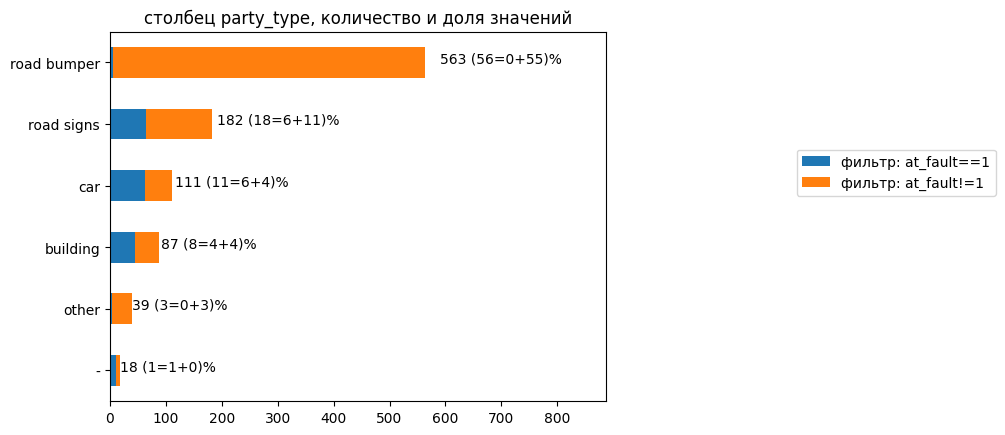

'⬇-------- столбец party_sobriety --------⬇'

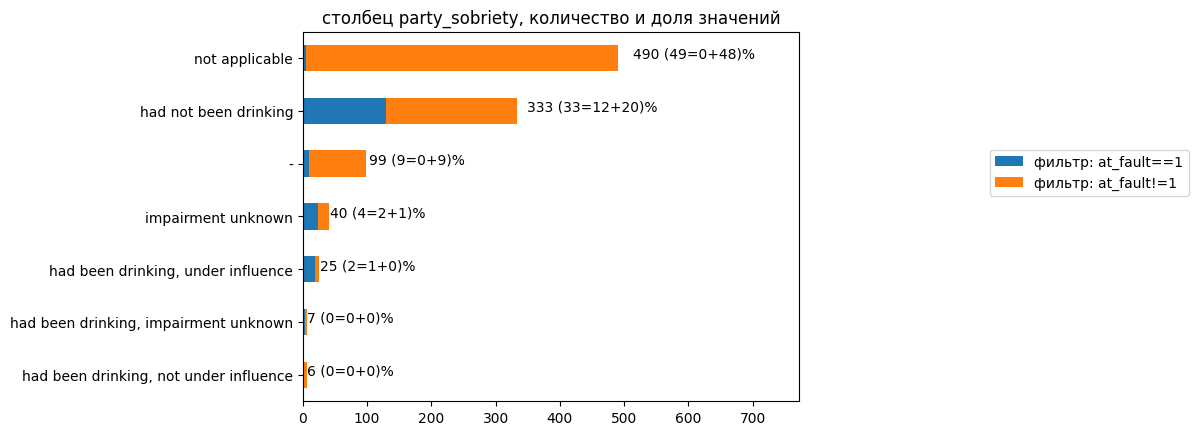

'⬇-------- столбец party_drug_physical --------⬇'

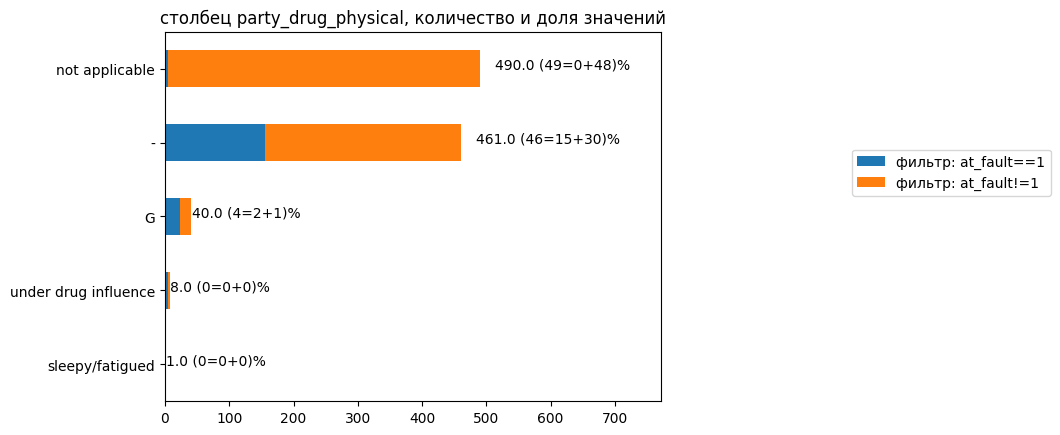

'⬇-------- Следующий признак: party_number --------⬇'

'фильтр: at_fault==1'

count    191.000000
mean       1.167539
std        0.374438
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        2.000000
Name: party_number, dtype: float64

'фильтр: at_fault!=1'

count    809.000000
mean       2.305315
std        0.903505
min        1.000000
25%        2.000000
50%        2.000000
75%        2.000000
max        9.000000
Name: party_number, dtype: float64

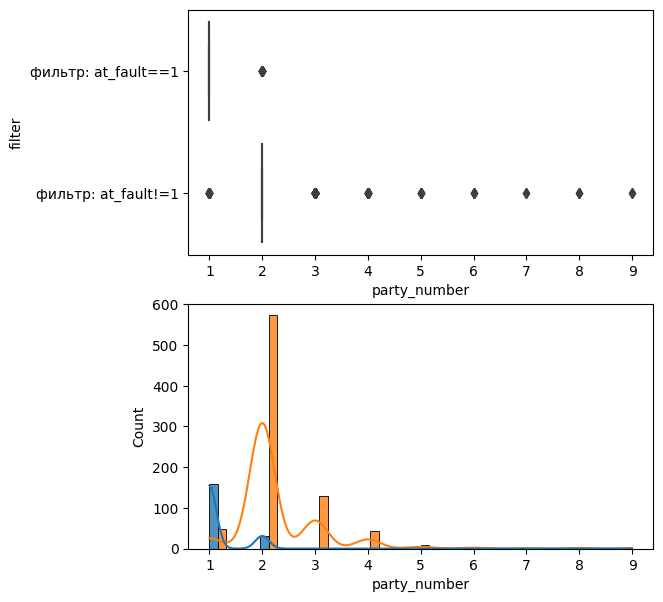

'⬇-------- Следующий признак: insurance_premium --------⬇'

'фильтр: at_fault==1'

count    191.000000
mean      35.227749
std       17.562721
min        2.000000
25%       22.500000
50%       34.500000
75%       47.000000
max       88.000000
Name: insurance_premium, dtype: float64

'фильтр: at_fault!=1'

count    809.000000
mean      35.745983
std       10.142643
min        0.000000
25%       34.500000
50%       34.500000
75%       34.500000
max       90.000000
Name: insurance_premium, dtype: float64

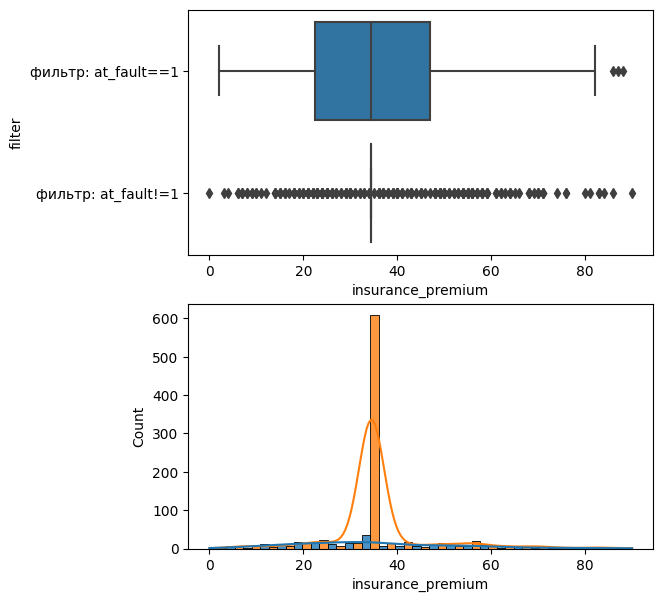

'⬇-------- Следующий признак: cellphone_in_use --------⬇'

'фильтр: at_fault==1'

count    191.000000
mean       0.031414
std        0.174891
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: cellphone_in_use, dtype: float64

'фильтр: at_fault!=1'

count    809.000000
mean       0.012361
std        0.110559
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: cellphone_in_use, dtype: float64

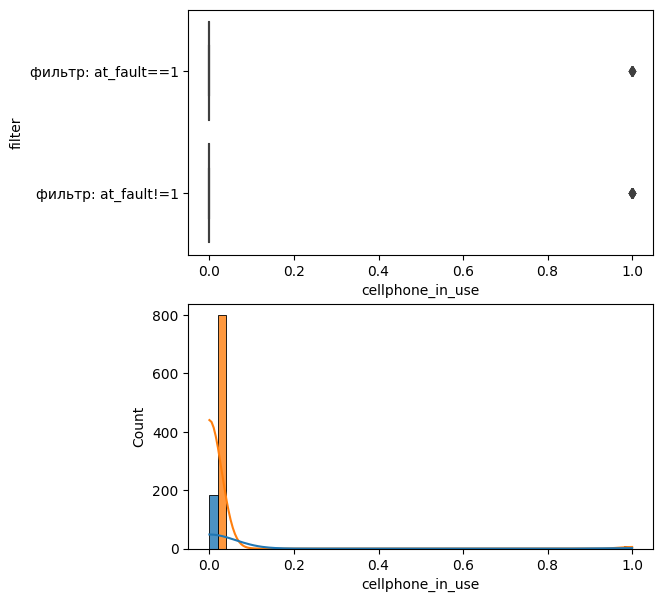

In [34]:
do_eda(df_parties, filters=["at_fault==1", "at_fault!=1"], ignore_columns=['id', 'case_id', 'at_fault'])

'⬇-------- столбец vehicle_type --------⬇'

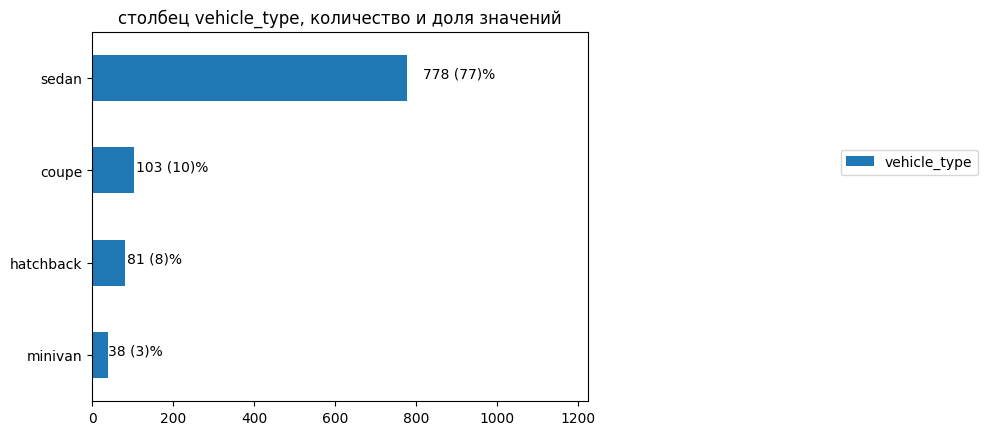

'⬇-------- столбец vehicle_transmission --------⬇'

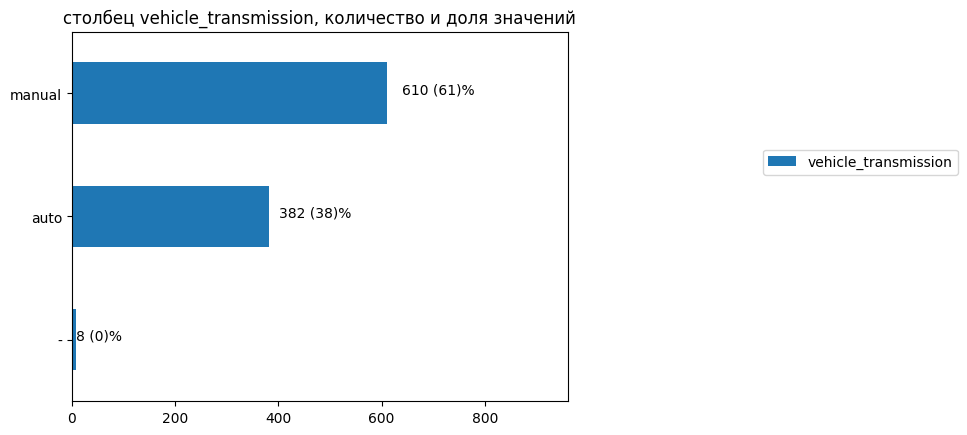

'⬇-------- Следующий признак: party_number --------⬇'

,party_number
count,1000.000000
mean,1.642000
std,0.711577
min,1.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,7.000000


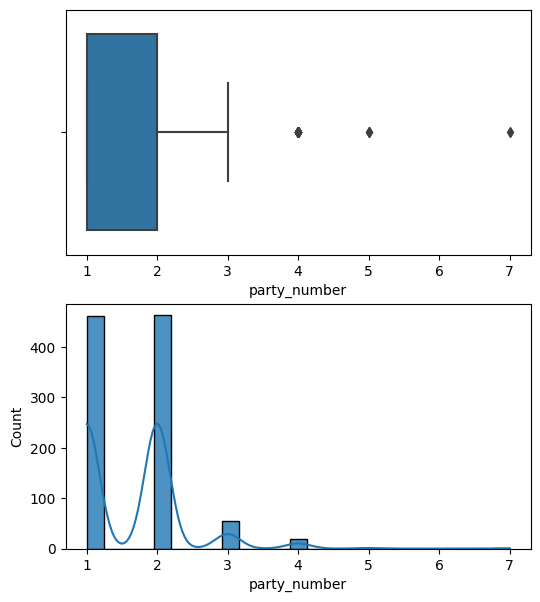

'⬇-------- Следующий признак: vehicle_age --------⬇'

,vehicle_age
count,1000.000000
mean,4.743000
std,3.120046
min,0.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,15.000000


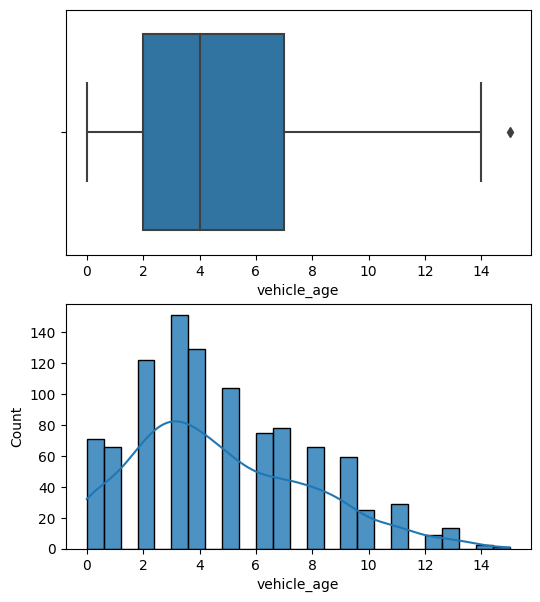

In [35]:
do_eda(df_vehicles, ignore_columns=['id', 'case_id'])

'⬇-------- столбец county_city_location --------⬇'

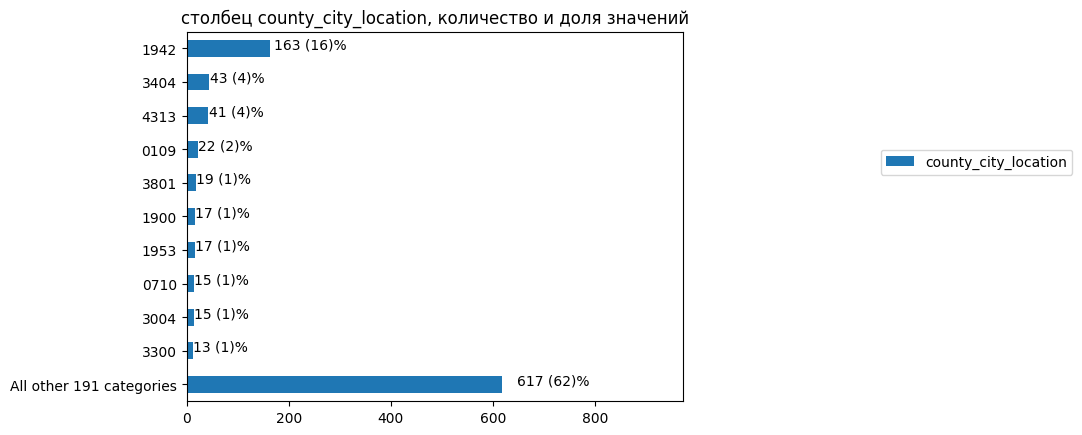

'⬇-------- столбец county_location --------⬇'

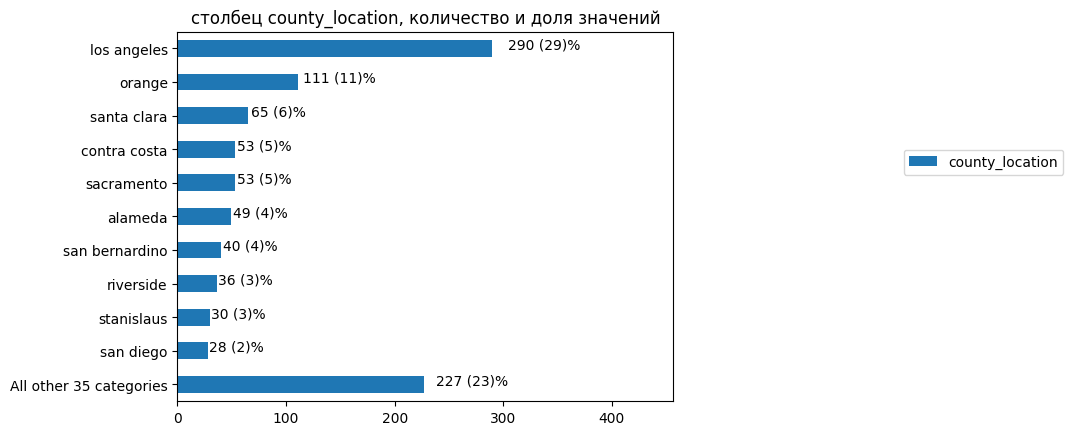

'⬇-------- столбец direction --------⬇'

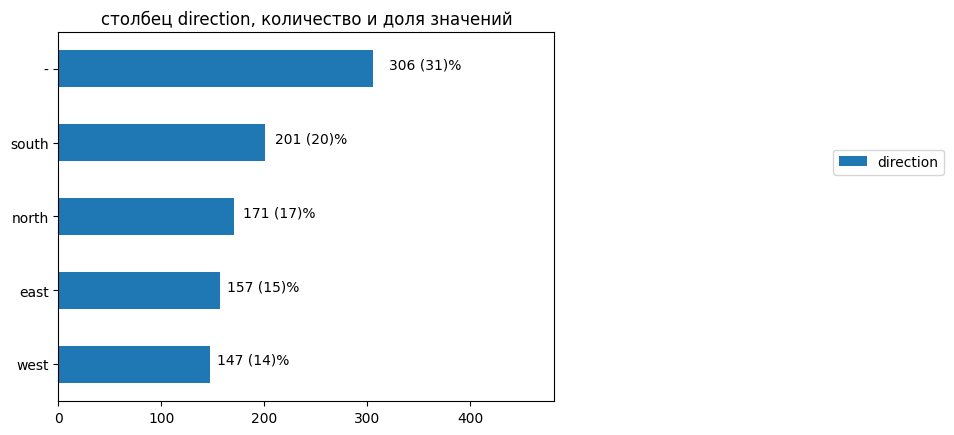

'⬇-------- столбец weather_1 --------⬇'

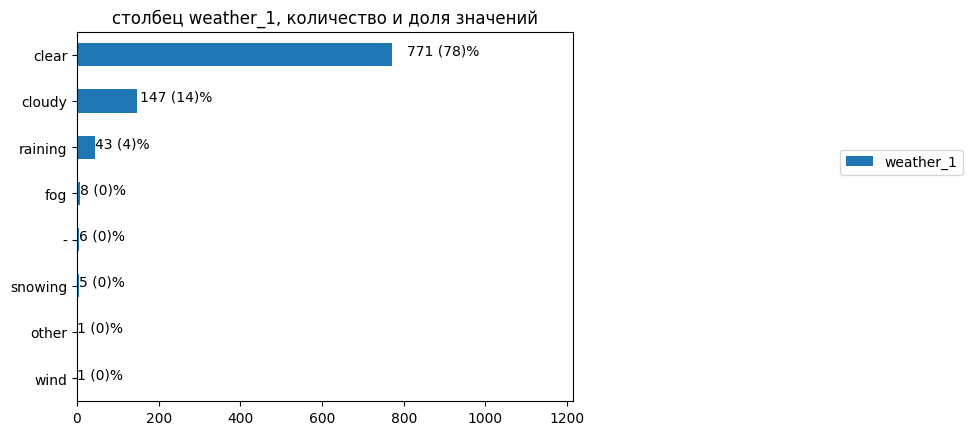

'⬇-------- столбец location_type --------⬇'

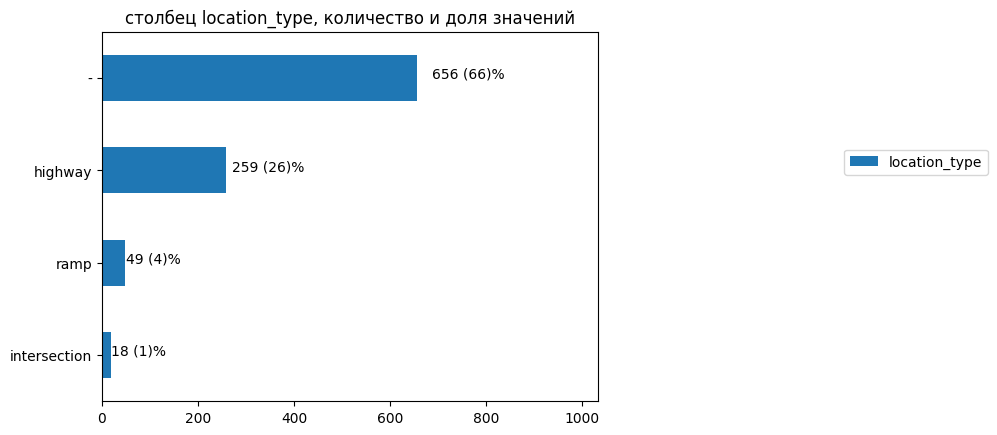

'⬇-------- столбец collision_damage --------⬇'

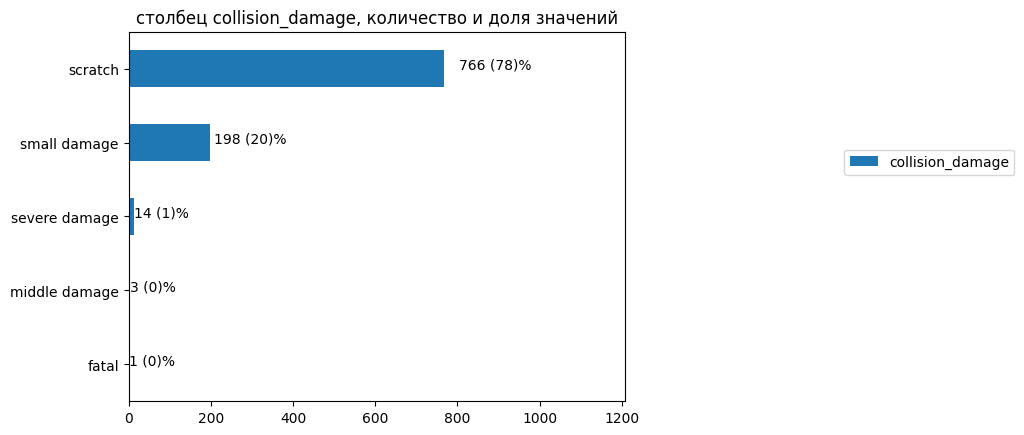

'⬇-------- столбец primary_collision_factor --------⬇'

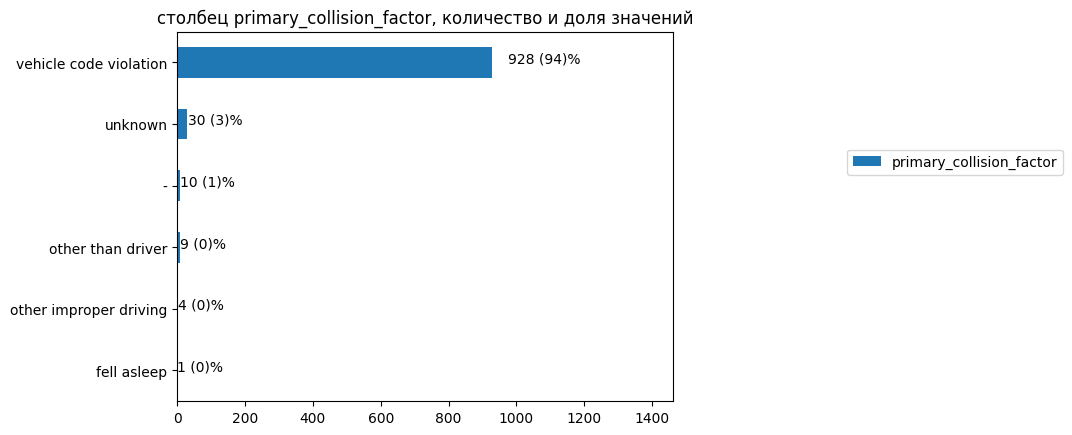

'⬇-------- столбец pcf_violation_category --------⬇'

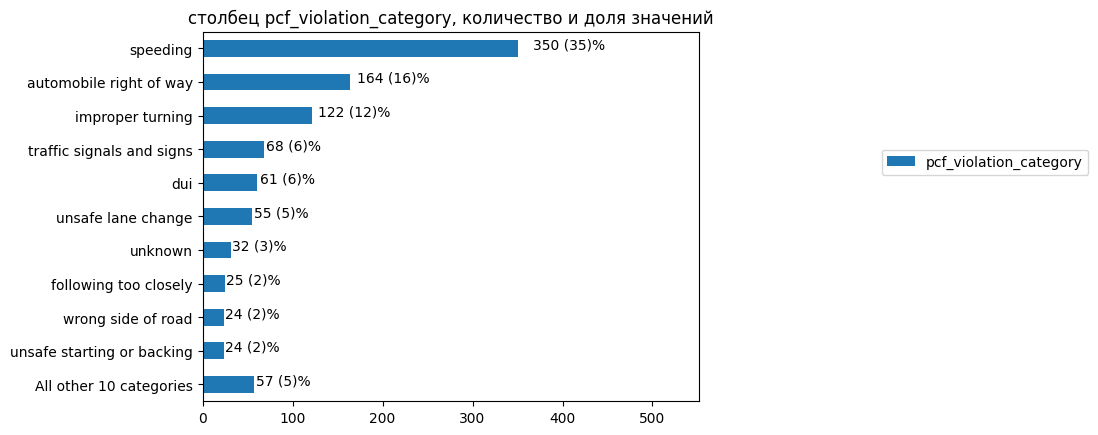

'⬇-------- столбец type_of_collision --------⬇'

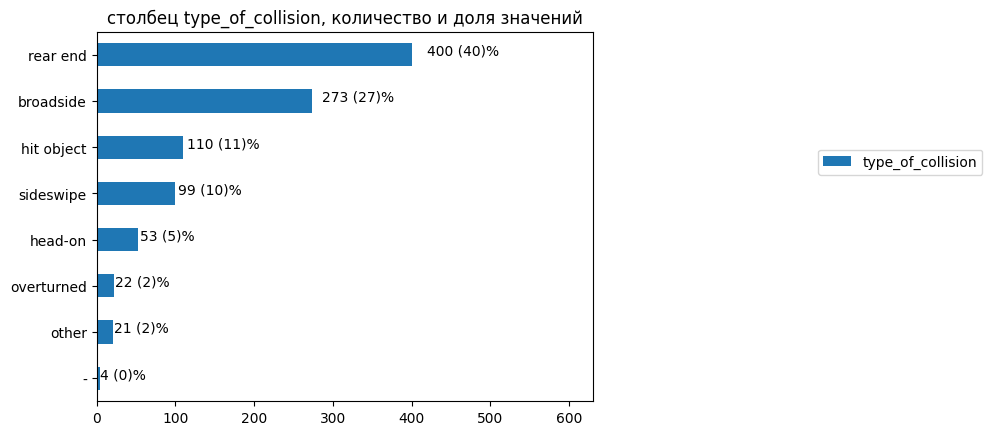

'⬇-------- столбец motor_vehicle_involved_with --------⬇'

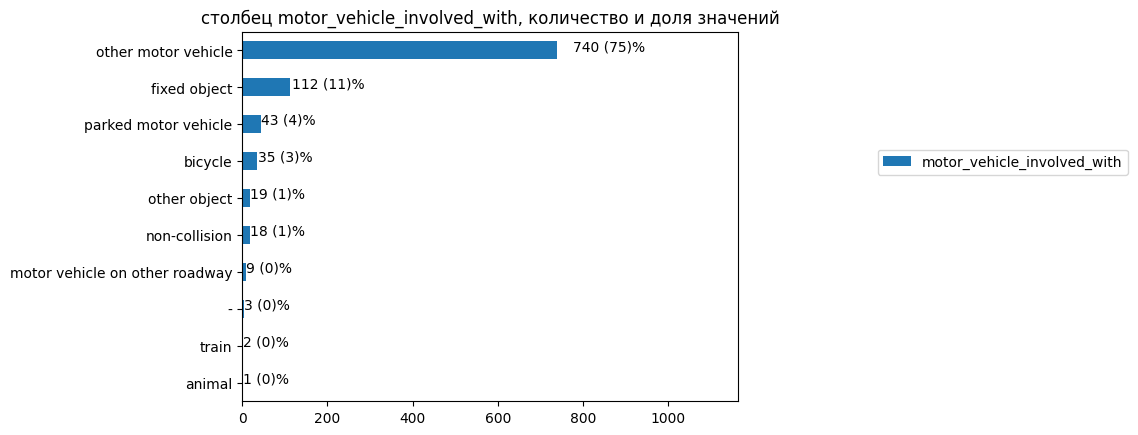

'⬇-------- столбец road_surface --------⬇'

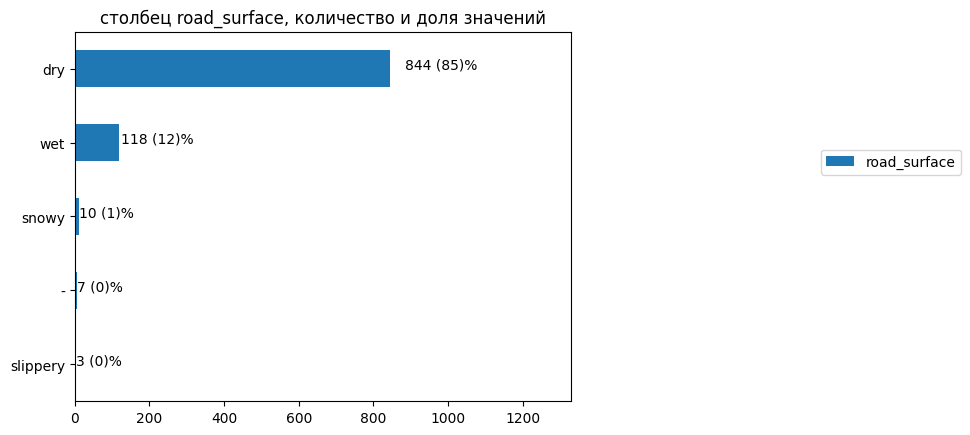

'⬇-------- столбец road_condition_1 --------⬇'

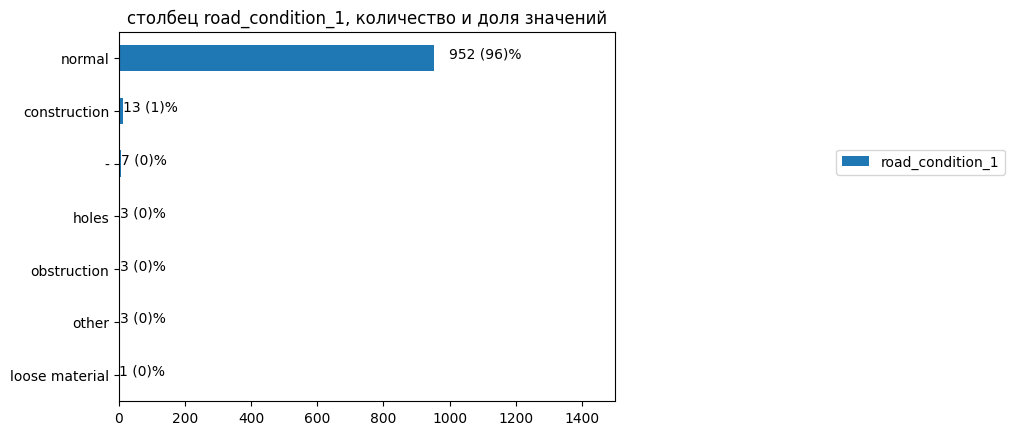

'⬇-------- столбец lighting --------⬇'

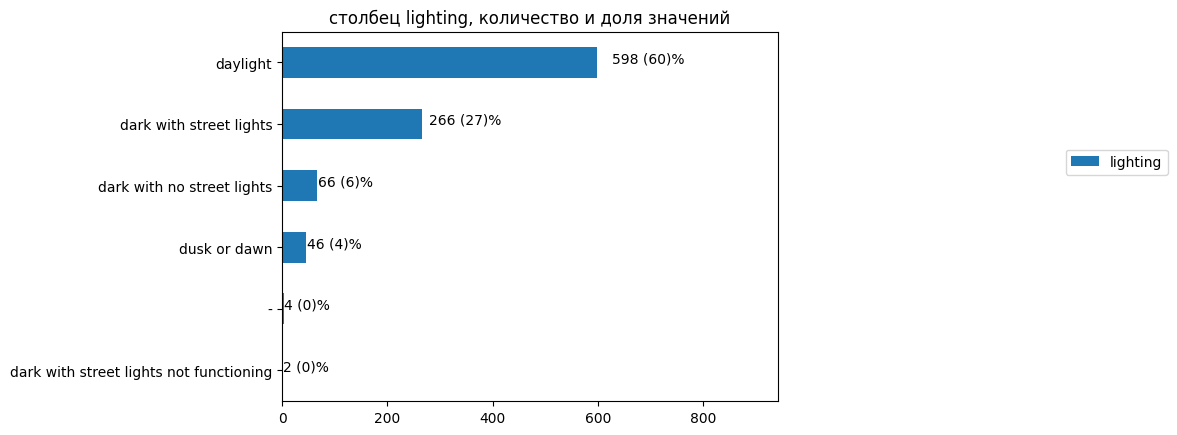

'⬇-------- столбец control_device --------⬇'

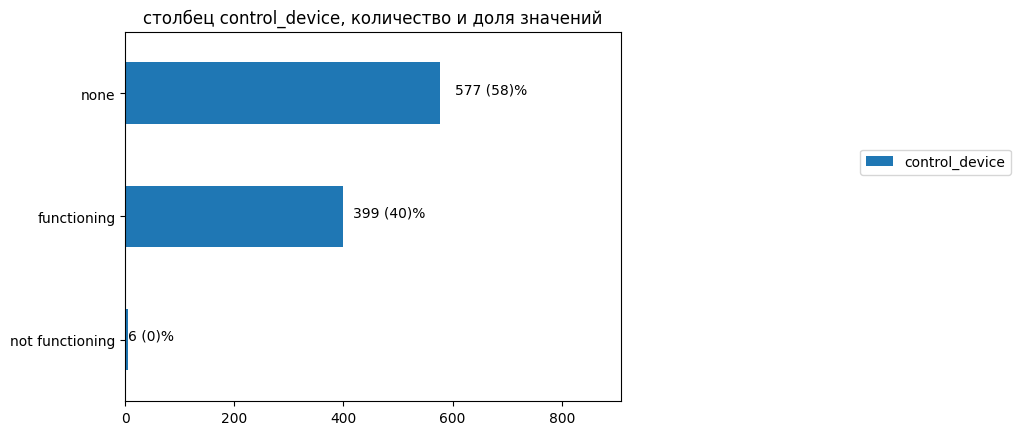

'⬇-------- Следующий признак: distance --------⬇'

,distance
count,982.000000
mean,408.459267
std,1245.364976
min,0.000000
25%,0.000000
50%,60.000000
75%,300.000000
max,21120.000000


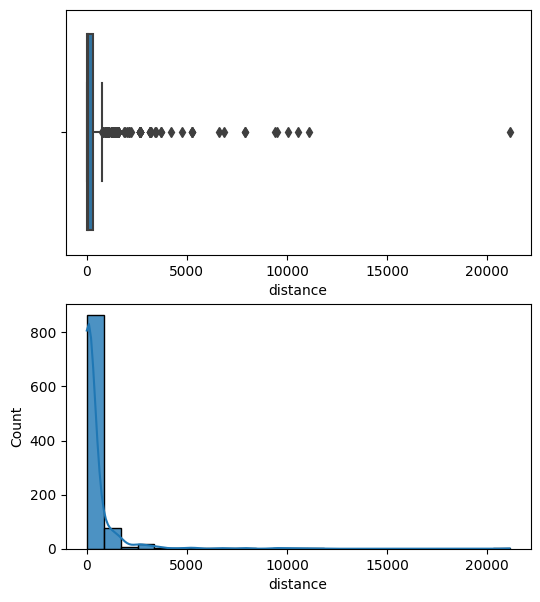

'⬇-------- Следующий признак: intersection --------⬇'

,intersection
count,982.000000
mean,0.300407
std,0.458669
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


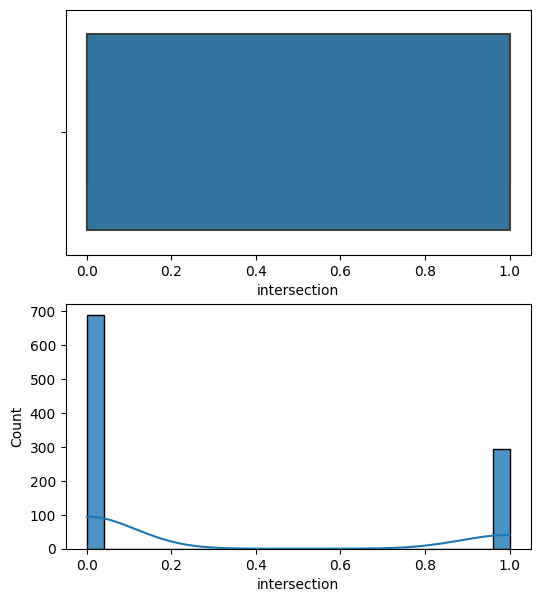

'⬇-------- Следующий признак: party_count --------⬇'

,party_count
count,982.000000
mean,2.076375
std,0.684227
min,1.000000
25%,2.000000
50%,2.000000
75%,2.000000
max,8.000000


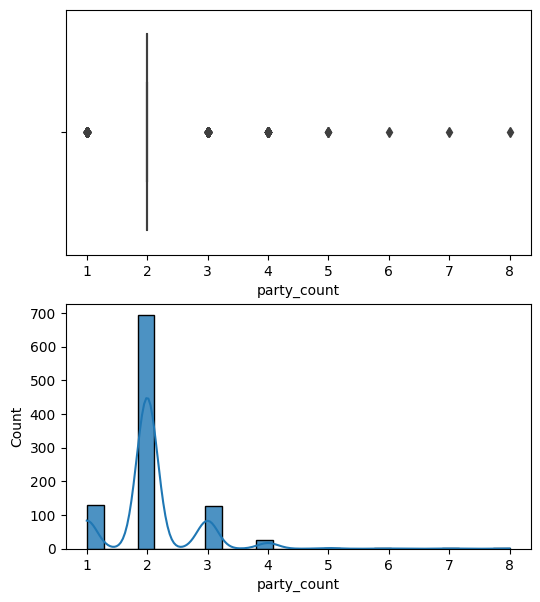

'⬇-------- Следующий признак: collision_date_year --------⬇'

,collision_date_year
count,982.0
mean,2009.0
std,0.0
min,2009.0
25%,2009.0
50%,2009.0
75%,2009.0
max,2009.0


c:\Users\Papa\.conda\envs\practicum\lib\site-packages\seaborn\distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)


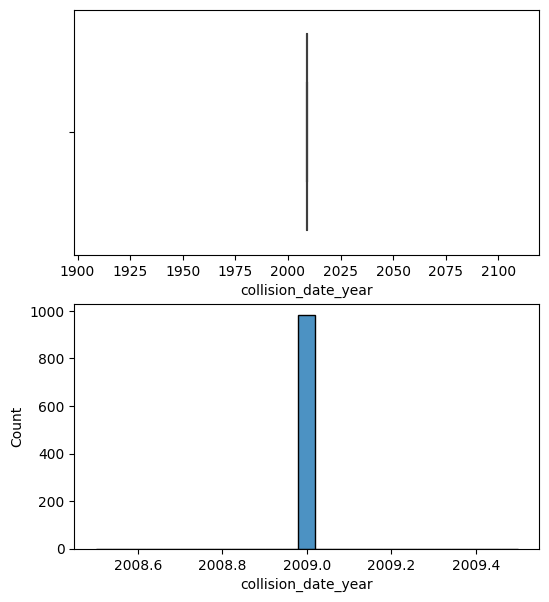

'⬇-------- Следующий признак: collision_date_month --------⬇'

,collision_date_month
count,982.000000
mean,1.280041
std,0.735019
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,11.000000


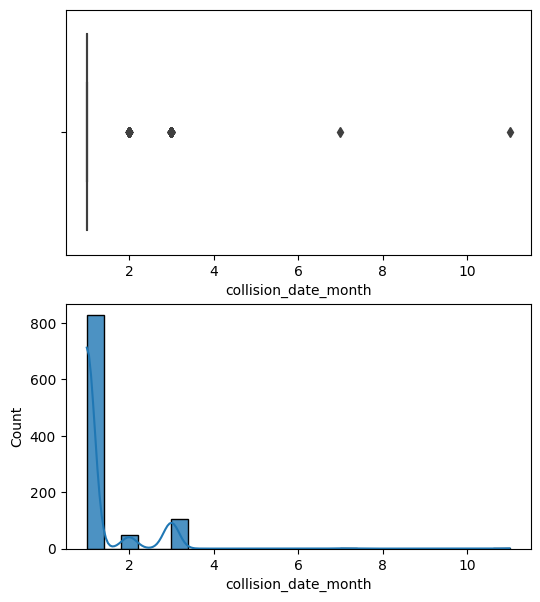

'⬇-------- Следующий признак: collision_date_day --------⬇'

,collision_date_day
count,982.000000
mean,14.631365
std,8.092140
min,1.000000
25%,8.000000
50%,14.000000
75%,21.000000
max,31.000000


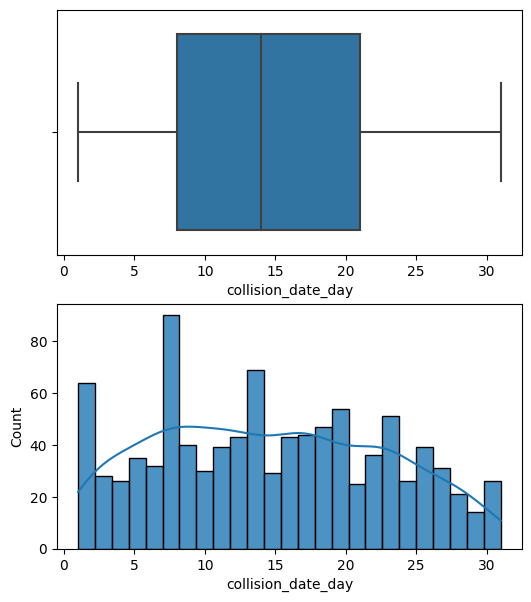

'⬇-------- Следующий признак: collision_date_weekday --------⬇'

,collision_date_weekday
count,982.000000
mean,2.986762
std,1.928600
min,0.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,6.000000


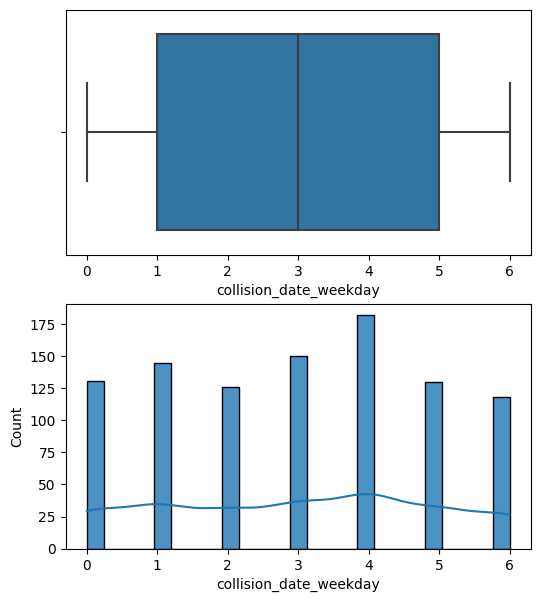

'⬇-------- Следующий признак: collision_time_hour --------⬇'

,collision_time_hour
count,982.000000
mean,13.264766
std,5.182811
min,0.000000
25%,10.000000
50%,14.000000
75%,17.000000
max,23.000000


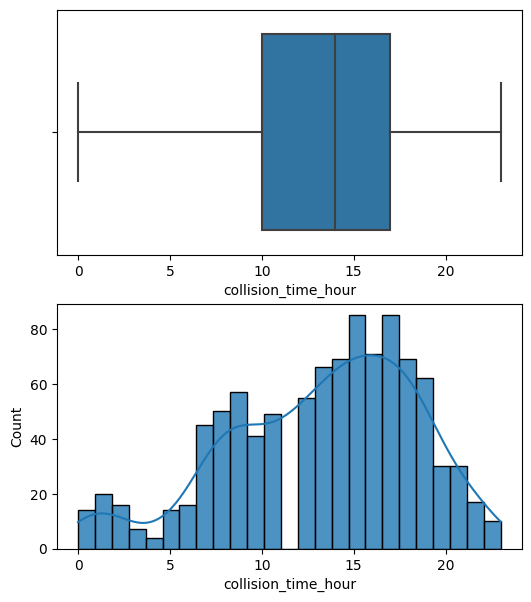

In [36]:
do_eda(df_collisions, ignore_columns=['case_id'])

In [37]:
df_collisions['intersection'].value_counts(normalize=True)

0.0    0.699593
1.0    0.300407
Name: intersection, dtype: float64

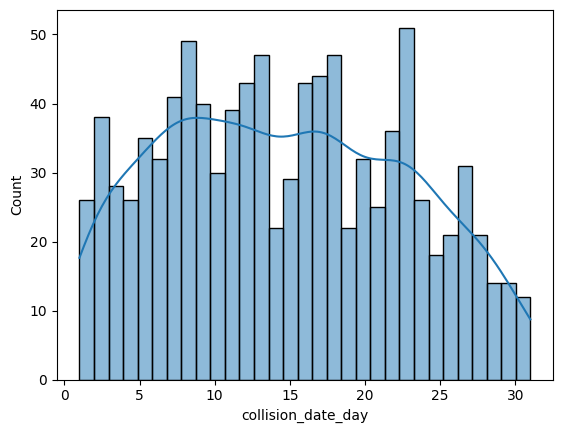

In [38]:
sns.histplot(df_collisions['collision_date_day'], kde=True, bins=31);

In [39]:
df_case_ids['db_year'].value_counts()

2021    1000
Name: db_year, dtype: int64

## Проведите статистический анализ факторов ДТП

### Выводы и задачи по итогам EDA

- статистика по участникам происшествий:
    - в 75+% участников двое
        - TOP3 Дополнительные участники ДТП: Другой автомобиль (64%), Неподвижный объект (16%), Припаркованный автомобиль (6%)
    - 77% участников были трезвыми
        - если участник "Был пьян, под влиянием" - то почти всегда он был виновен (в ~3% всех ДТП виновен против ~0% невиновен)
    - 89% от всех участников происшествия = car 
- информация о происшествиях
    - **больше всего ДТП происходит в марте**
    - в 94% Основной фактор аварии - нарушение правил ПДД
        - TOP3 категорий нарушения - скорость (31%), неправильный поворот (16%), право/преимущество проезда (11%)
    - 80% происшествий было в ясную погоду
    - лидер (30%) по месту происшествия - Highway
        - TOP3 Тип аварии: Столкновение задней частью (33%), Боковой удар (19%), Сторона (17%)
        - в 77% случаев дтп было не на перекрёстке
    - 60% - мелкие повреждения и 24% царапины
    - серьёзных повреждений 2%, фатальных - ~0%
    - в 96% случаев дорожное покрытие - нормальное
    - в 67% случаев был дневной свет
    - пиковые часы дтп - с 15 до 17 часов
    - лидер (31%) по происшествиям - Лос-Анжелес

Итого, наиболее массовый случай - это нарушение ПДД на скоростных дорогах между двумя участниками с малозначительными повреждениями.


In [40]:
df_collistions_per_months_research = load_df(engine, f'SELECT collision_date FROM collisions;')

,collision_date
0,2009-01-22
1,2009-01-03
2,2009-01-11
3,2009-01-11
4,2009-01-02


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400000 entries, 0 to 1399999
Data columns (total 1 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   collision_date  1400000 non-null  object
dtypes: object(1)
memory usage: 10.7+ MB


None

In [41]:
df_collistions_per_months_research = split_date(df_collistions_per_months_research,
    date_column='collision_date', needed_parts='my', format='%Y-%m-%d', drop_date_column=True)

In [42]:
df_collistions_per_months_research.head()

,collision_date_year,collision_date_month
0,2009,1
1,2009,1
2,2009,1
3,2009,1
4,2009,1


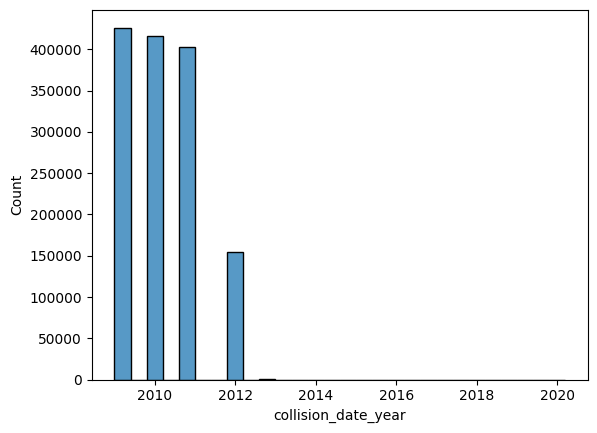

In [43]:
sns.histplot(df_collistions_per_months_research, x='collision_date_year', binwidth=0.4);

данные за 2012 года не полные, удаляем их:

In [44]:
df_collistions_per_months_research = df_collistions_per_months_research.query('collision_date_year < 2012')

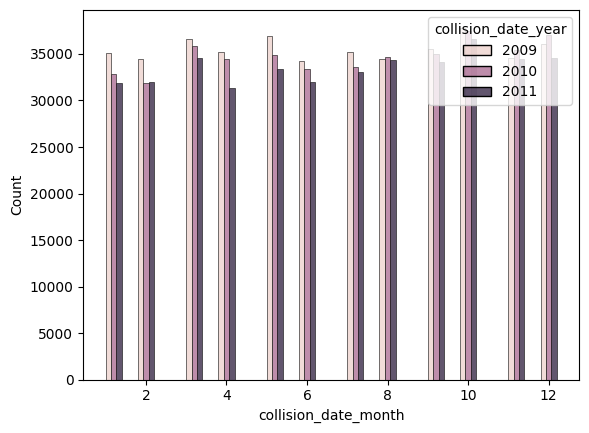

In [45]:
ax = sns.histplot(df_collistions_per_months_research, x='collision_date_month', 
             hue='collision_date_year', multiple='dodge', binwidth=0.4);

#ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left');
#sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))


Почему-то оба способа сдвига легенды не сработали в данном случае..

такой способ

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left');

- выдвигает легенду вправо, но легенда пустая

такой способ:

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

- выдаёт ошибку

AttributeError: module 'seaborn' has no attribute 'move_legend'

chatgpt пишет:

*Понял, тогда ваш случай — один из особых: sns.histplot с multiple='dodge' иногда не передаёт легенду в Matplotlib, особенно при работе с категориальными признаками (например, месяцами в виде строк). Такое поведение — особенность реализации histplot.*

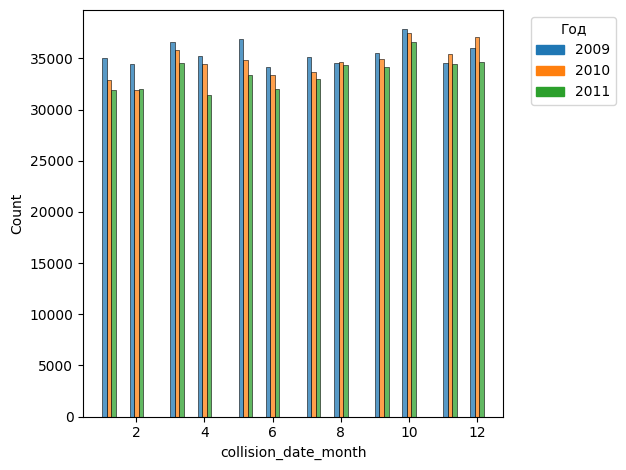

In [46]:
years = df_collistions_per_months_research['collision_date_year'].unique()
palette = sns.color_palette()[:len(years)]

ax = sns.histplot(df_collistions_per_months_research, x='collision_date_month', 
             hue='collision_date_year', multiple='dodge', binwidth=0.4,
             palette=palette,);

# Создаём ручные "патчи" (ярлыки для легенды)
handles = [Patch(color=palette[i], label=year) for i, year in enumerate(sorted(years))]

# Добавляем вручную легенду в нужное место
ax.legend(handles=handles, title='Год', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Результат исследования: в марте происходит наибольшее количество аварий.

удалим явные аномалии:

In [47]:
##v2 df_vehicles = df_vehicles.query('vehicle_age < 50')

### 6 задач для предстоящего обсуждения:
1. Проведите анализ зависимости между состоянием опьянения виновников и серьёзности ущерба
1. Проведите анализ зависимости между состоянием опьянения виновников и категориями нарушений ПДД
1. Проведите анализ зависимости между городом и состоянием дороги
1. Проведите анализ зависимости между погодой и состоянием дороги
1. Проведите анализ зависимости между средним возрастом автомобилей-участников ДТП и серьёзности ущерба
1. Проведите анализ зависимости между средним возрастом автомобилей-участников ДТП и средним размером страховки участников ДТП

### Задача-1

План решения задачи-1: анализ зависимости между состоянием опьянения виновников и серьёзности ущерба
1. составьте и выполните SQL-запрос, объединяющий party_sobriety таблицы parites с collision_damage таблицы collisions
1. постройте график
1. сделайте вывод о зависимости

Решение:

In [48]:
sql_req =f'''
SELECT
    party_sobriety
    ,collision_damage
FROM parties as p
LEFT JOIN collisions as c ON p.case_id = c.case_id
WHERE p.at_fault=1
'''
df_task_1 = load_df(engine, sql_req)

,party_sobriety,collision_damage
0,had not been drinking,scratch
1,had not been drinking,fatal
2,impairment unknown,middle damage
3,"had been drinking, under influence",small damage
4,had not been drinking,scratch


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1288127 entries, 0 to 1288126
Data columns (total 2 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   party_sobriety    1259287 non-null  object
 1   collision_damage  1288127 non-null  object
dtypes: object(2)
memory usage: 19.7+ MB


None

In [49]:
sns.set_theme(context='notebook', style='darkgrid', palette='deep', font='sans-serif', font_scale=1, color_codes=True, rc=None)

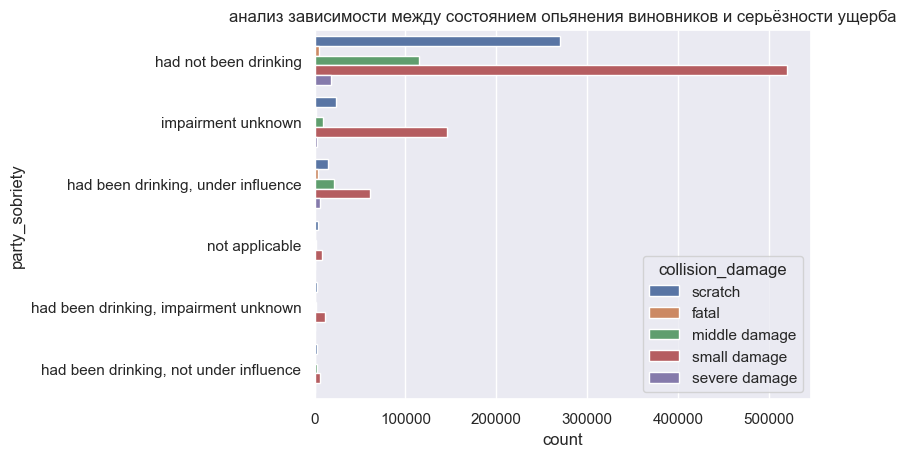

In [50]:
ax = sns.countplot(data=df_task_1, y='party_sobriety', hue='collision_damage');
ax.set_title('анализ зависимости между состоянием опьянения виновников и серьёзности ущерба');

Вывод: урон в целом, и а частности фатальный - больше всего, если человек не был пьян.

### Задача-5

План решения задачи-5: Проведите анализ зависимости между средним возрастом автомобилей-участников ДТП и серьёзности ущерба
1. составьте и выполните SQL-запрос, объединяющий vehicle_age таблицы Vehicles с collision_damage таблицы collisions
1. постройте график
1. сделайте вывод о зависимости

Решение:

In [51]:
sql_req =f'''
SELECT
    vehicle_age
    ,collision_damage
FROM Vehicles as v
LEFT JOIN collisions as c ON v.case_id = c.case_id
WHERE vehicle_age < 50
'''
df_task_5 = load_df(engine, sql_req)

,vehicle_age,collision_damage
0,8,small damage
1,11,scratch
2,6,small damage
3,3,small damage
4,7,scratch


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 996635 entries, 0 to 996634
Data columns (total 2 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   vehicle_age       996635 non-null  int64 
 1   collision_damage  996635 non-null  object
dtypes: int64(1), object(1)
memory usage: 15.2+ MB


None

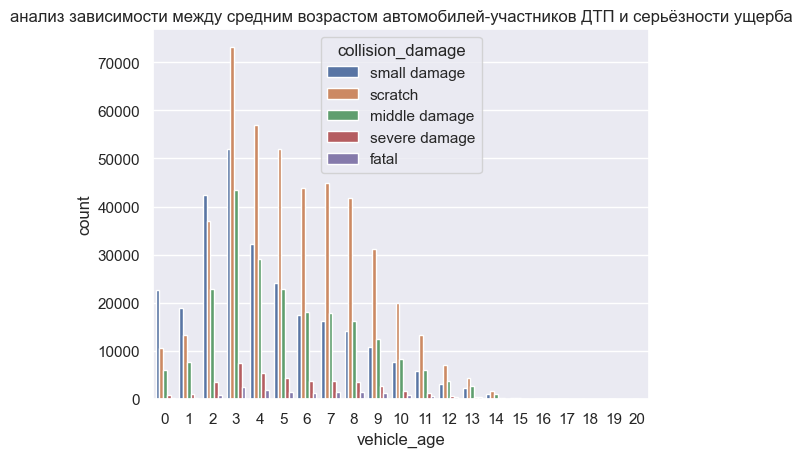

In [52]:
ax = sns.countplot(data=df_task_5, x='vehicle_age', hue='collision_damage');
ax.set_title('анализ зависимости между средним возрастом автомобилей-участников ДТП и серьёзности ущерба');

Вывод: зависимости между общим количеством ДТП и годом - есть. Но по серьёзности ущерба - зависимость между возрастами явно не прослеживается.

Нет такого, например, что для старых машин более характерен малый ущёрб, а для молодых - более характерее большой ущерб. Наоборот - пропорции уровня ущерба между разными годами - примерно похожа.

## Создайте модель для оценки водительского риска

### повторная загрузка и предобработка данных

В качестве целевого признака выберем parties.at_fault.

Учтём также ограничения на данные из постановки задачи.

In [53]:
sql_req =f'''
SELECT
-- целевой признак
    at_fault
-- полезные и не приводящие к утечке признаки:
-- collisions:
    ,county_city_location   -- доступно из навигатора
    ,county_location        -- доступно из навигатора
    ,distance               -- доступно из навигатора
    ,direction              -- доступно из навигатора
    ,intersection           -- доступно из навигатора
    ,weather_1              -- доступно из прогноза погоды
    ,location_type          -- доступно из навигатора
    ,road_surface           -- доступно из навигатора
    ,road_condition_1       -- доступно из навигатора
    ,lighting               -- доступно из часов
    ,control_device         -- доступно из свойств авто (датчик контроля полосы и т. п., вероятно)
    ,collision_date         -- доступно из часов и роадмапа маршрута
    ,collision_time         -- доступно из часов и роадмапа маршрута
-- vehicles:
    ,vehicle_type           -- доступно арендодателю
    ,vehicle_transmission   -- доступно арендодателю
    ,vehicle_age            -- доступно арендодателю
--  parties
    ,insurance_premium      -- доступно арендодателю
    ,cellphone_in_use       -- доступно в случае аренды через приложение

FROM collisions as c
INNER JOIN Vehicles as v ON v.case_id = c.case_id
INNER JOIN parties as p ON p.case_id = c.case_id AND v.party_number = p.party_number 
WHERE party_type='car' and EXTRACT(YEAR FROM collision_date)=2012 and vehicle_age<50 
    and collision_damage <> 'scratch'
'''
df = load_df(engine, sql_req)

,at_fault,county_city_location,county_location,distance,direction,intersection,weather_1,location_type,road_surface,road_condition_1,lighting,control_device,collision_date,collision_time,vehicle_type,vehicle_transmission,vehicle_age,insurance_premium,cellphone_in_use
0,1,3711,san diego,1500.0,south,0.0,clear,highway,dry,normal,dark with street lights,none,2012-01-20,01:50:00,sedan,manual,3,NaN,0.0
1,0,1101,glenn,55.0,north,0.0,cloudy,None,wet,normal,daylight,none,2012-04-11,14:10:00,sedan,auto,3,20.0,0.0
2,1,3010,orange,0.0,east,0.0,clear,None,dry,normal,daylight,none,2012-04-17,17:09:00,sedan,auto,3,21.0,NaN
3,0,3604,san bernardino,1584.0,south,0.0,cloudy,ramp,dry,normal,daylight,functioning,2012-04-25,19:12:00,sedan,auto,5,33.0,0.0
4,1,4000,san luis obispo,50.0,north,0.0,clear,None,dry,normal,daylight,functioning,2012-04-28,08:00:00,sedan,auto,3,23.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54552 entries, 0 to 54551
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   at_fault              54552 non-null  int64  
 1   county_city_location  54552 non-null  object 
 2   county_location       54552 non-null  object 
 3   distance              54552 non-null  float64
 4   direction             42096 non-null  object 
 5   intersection          54384 non-null  float64
 6   weather_1             54387 non-null  object 
 7   location_type         25510 non-null  object 
 8   road_surface          54223 non-null  object 
 9   road_condition_1      54315 non-null  object 
 10  lighting              54400 non-null  object 
 11  control_device        54346 non-null  object 
 12  collision_date        54552 non-null  object 
 13  collision_time        54468 non-null  object 
 14  vehicle_type          54552 non-null  object 
 15  vehicle_transmissio

None

In [54]:
df = df.query('vehicle_age <= 10')

Повторим предобратку:

In [55]:
show_nans (df)

'empty parts:'

direction               22.46%
intersection             0.31%
weather_1                 0.3%
location_type           53.05%
road_surface              0.6%
road_condition_1         0.43%
lighting                 0.28%
control_device           0.37%
collision_time           0.16%
vehicle_transmission     1.04%
insurance_premium         0.8%
cellphone_in_use         7.64%
dtype: object

Пропуски:
- постараемся заполнить, если признак важный и пропусков много (иначе потеряем много данных - можно сказать, нет выбора)
- удалим, если признак важный, и пропусков мало (т. к. удаление малой доли записей не сильно повлияет на результат, и ни к чему тогда связываться с синтетикой для важных признаков)
- заполним, если признак неважный

In [56]:
df = fill_by_median(df, ['insurance_premium', 'cellphone_in_use'])

In [57]:
df = fill_by_value(df, ['direction', 'weather_1', 'location_type', 
                        'road_surface', 'road_condition_1', 'lighting', 'vehicle_transmission'], '-')
df = df.dropna(subset=['intersection', 'control_device', 'collision_time'])

In [58]:
df = split_date(df, date_column='collision_date', needed_parts='ymdw', format='%Y-%m-%d', drop_date_column=True)
df = split_date(df, date_column='collision_time', needed_parts='h', format='%H:%M:%S', drop_date_column=True)

In [59]:
display(df.head())
display(df.info())

,at_fault,county_city_location,county_location,distance,direction,intersection,weather_1,location_type,road_surface,road_condition_1,...,vehicle_type,vehicle_transmission,vehicle_age,insurance_premium,cellphone_in_use,collision_date_year,collision_date_month,collision_date_day,collision_date_weekday,collision_time_hour
0,1,3711,san diego,1500.0,south,0.0,clear,highway,dry,normal,...,sedan,manual,3,33.0,0.0,2012,1,20,4,1
1,0,1101,glenn,55.0,north,0.0,cloudy,-,wet,normal,...,sedan,auto,3,20.0,0.0,2012,4,11,2,14
2,1,3010,orange,0.0,east,0.0,clear,-,dry,normal,...,sedan,auto,3,21.0,0.0,2012,4,17,1,17
3,0,3604,san bernardino,1584.0,south,0.0,cloudy,ramp,dry,normal,...,sedan,auto,5,33.0,0.0,2012,4,25,2,19
4,1,4000,san luis obispo,50.0,north,0.0,clear,-,dry,normal,...,sedan,auto,3,23.0,0.0,2012,4,28,5,8


<class 'pandas.core.frame.DataFrame'>
Int64Index: 50993 entries, 0 to 54551
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   at_fault                50993 non-null  int64  
 1   county_city_location    50993 non-null  object 
 2   county_location         50993 non-null  object 
 3   distance                50993 non-null  float64
 4   direction               50993 non-null  object 
 5   intersection            50993 non-null  float64
 6   weather_1               50993 non-null  object 
 7   location_type           50993 non-null  object 
 8   road_surface            50993 non-null  object 
 9   road_condition_1        50993 non-null  object 
 10  lighting                50993 non-null  object 
 11  control_device          50993 non-null  object 
 12  vehicle_type            50993 non-null  object 
 13  vehicle_transmission    50993 non-null  object 
 14  vehicle_age             50993 non-null

None

In [60]:
df = display_drop_full_duplicates(df)

'28 full duplicates are dropped'

In [61]:
print_unique_text_features(df)

'⬇-------- Feature "county_city_location"--------⬇'

array(['0100', '0101', '0102', '0103', '0104', '0105', '0106', '0107',
       '0108', '0109', '0110', '0111', '0112', '0113', '0198', '0200',
       '0300', '0302', '0303', '0305', '0400', '0402', '0403', '0404',
       '0405', '0500', '0501', '0600', '0601', '0602', '0700', '0701',
       '0702', '0703', '0704', '0705', '0706', '0707', '0708', '0709',
       '0710', '0711', '0712', '0714', '0715', '0716', '0734', '0790',
       '0791', '0792', '0800', '0900', '0901', '0902', '1000', '1001',
       '1004', '1005', '1007', '1008', '1011', '1012', '1013', '1015',
       '1100', '1101', '1102', '1200', '1201', '1203', '1205', '1300',
       '1301', '1302', '1304', '1305', '1306', '1400', '1401', '1500',
       '1501', '1502', '1503', '1504', '1505', '1506', '1507', '1508',
       '1509', '1510', '1511', '1515', '1600', '1601', '1602', '1603',
       '1690', '1700', '1701', '1702', '1800', '1801', '1900', '1901',
       '1902', '1903', '1905', '1906', '1907', '1908', '1909', '1910',
      

'⬇-------- Feature "county_location"--------⬇'

array(['alameda', 'alpine', 'amador', 'butte', 'calaveras', 'colusa',
       'contra costa', 'del norte', 'el dorado', 'fresno', 'glenn',
       'humboldt', 'imperial', 'inyo', 'kern', 'kings', 'lake', 'lassen',
       'los angeles', 'madera', 'marin', 'mariposa', 'mendocino',
       'merced', 'modoc', 'mono', 'monterey', 'napa', 'nevada', 'orange',
       'placer', 'plumas', 'riverside', 'sacramento', 'san benito',
       'san bernardino', 'san diego', 'san francisco', 'san joaquin',
       'san luis obispo', 'san mateo', 'santa barbara', 'santa clara',
       'santa cruz', 'shasta', 'sierra', 'siskiyou', 'solano', 'sonoma',
       'stanislaus', 'sutter', 'tehama', 'trinity', 'tulare', 'tuolumne',
       'ventura', 'yolo', 'yuba'], dtype=object)

'⬇-------- Feature "direction"--------⬇'

array(['-', 'east', 'north', 'south', 'west'], dtype=object)

'⬇-------- Feature "weather_1"--------⬇'

array(['-', 'clear', 'cloudy', 'fog', 'other', 'raining', 'snowing',
       'wind'], dtype=object)

'⬇-------- Feature "location_type"--------⬇'

array(['-', 'highway', 'intersection', 'ramp'], dtype=object)

'⬇-------- Feature "road_surface"--------⬇'

array(['-', 'dry', 'slippery', 'snowy', 'wet'], dtype=object)

'⬇-------- Feature "road_condition_1"--------⬇'

array(['-', 'construction', 'flooded', 'holes', 'loose material',
       'normal', 'obstruction', 'other', 'reduced width'], dtype=object)

'⬇-------- Feature "lighting"--------⬇'

array(['-', 'dark with no street lights', 'dark with street lights',
       'dark with street lights not functioning', 'daylight',
       'dusk or dawn'], dtype=object)

'⬇-------- Feature "control_device"--------⬇'

array(['functioning', 'none', 'not functioning', 'obscured'], dtype=object)

'⬇-------- Feature "vehicle_type"--------⬇'

array(['coupe', 'other', 'sedan'], dtype=object)

'⬇-------- Feature "vehicle_transmission"--------⬇'

array(['-', 'auto', 'manual'], dtype=object)

### повторный EDA

In [62]:
df['at_fault'].value_counts()

1    25705
0    25260
Name: at_fault, dtype: int64

'⬇-------- столбец county_city_location --------⬇'

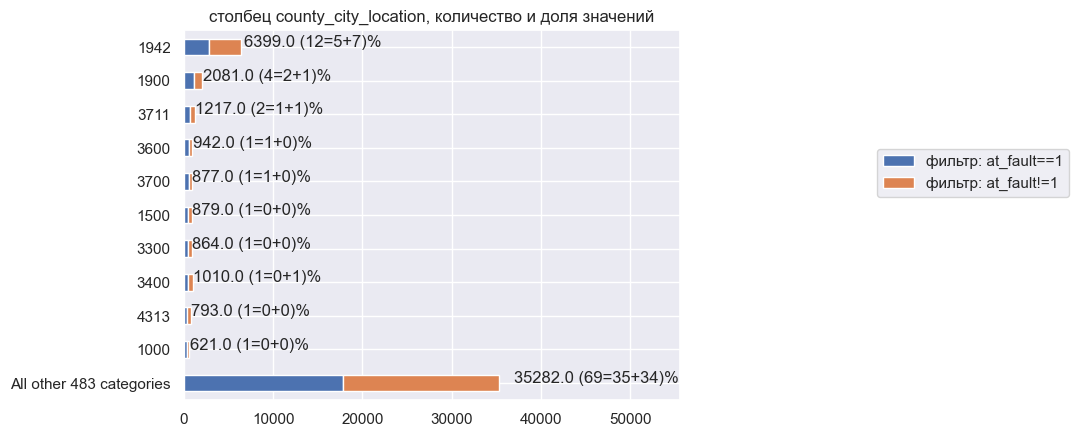

'⬇-------- столбец county_location --------⬇'

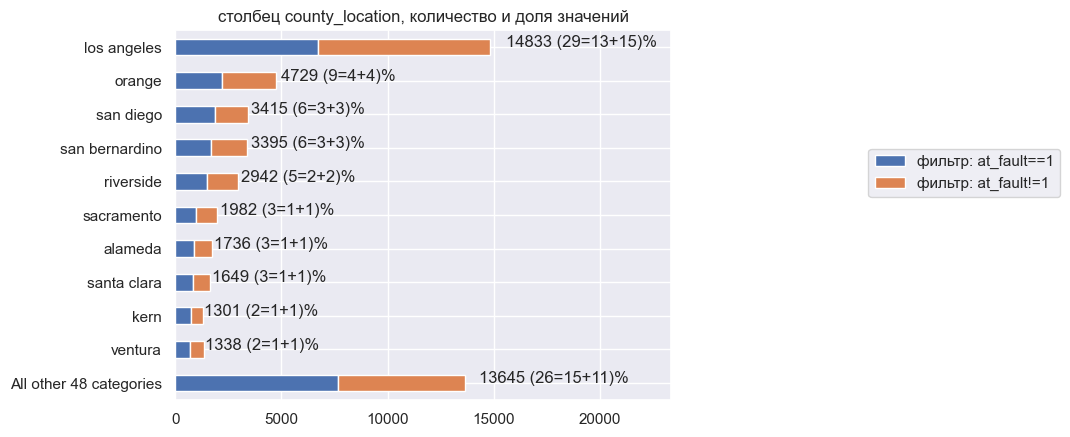

'⬇-------- столбец direction --------⬇'

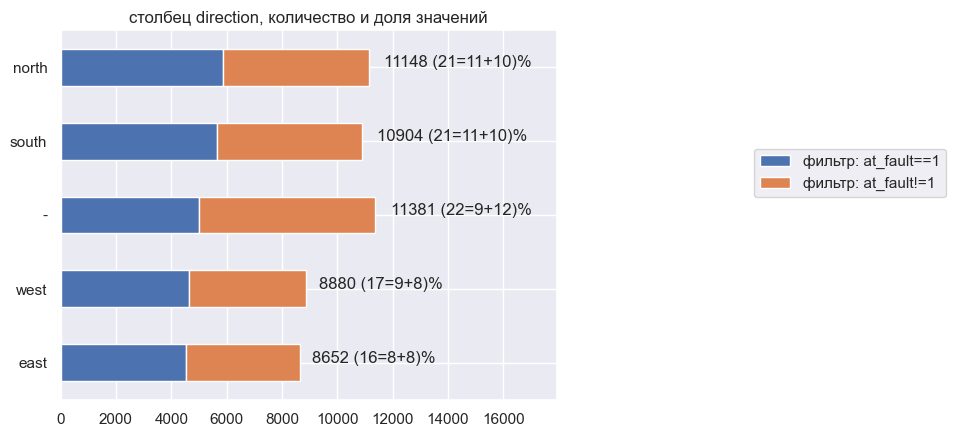

'⬇-------- столбец weather_1 --------⬇'

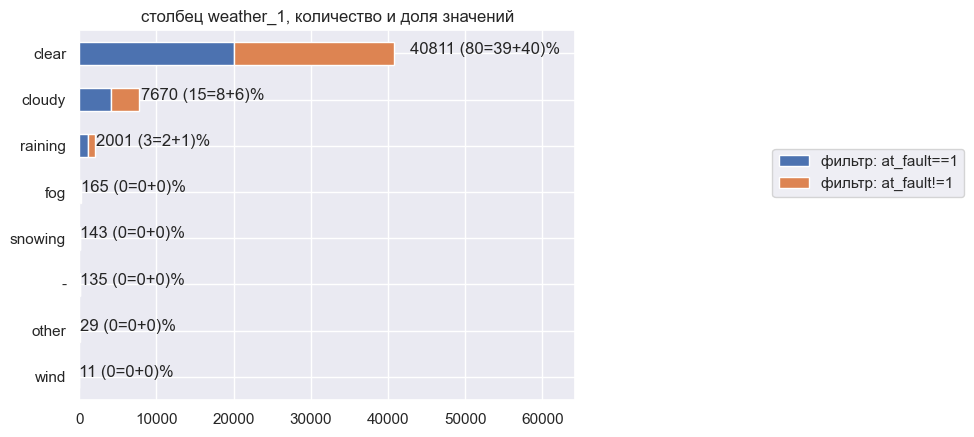

'⬇-------- столбец location_type --------⬇'

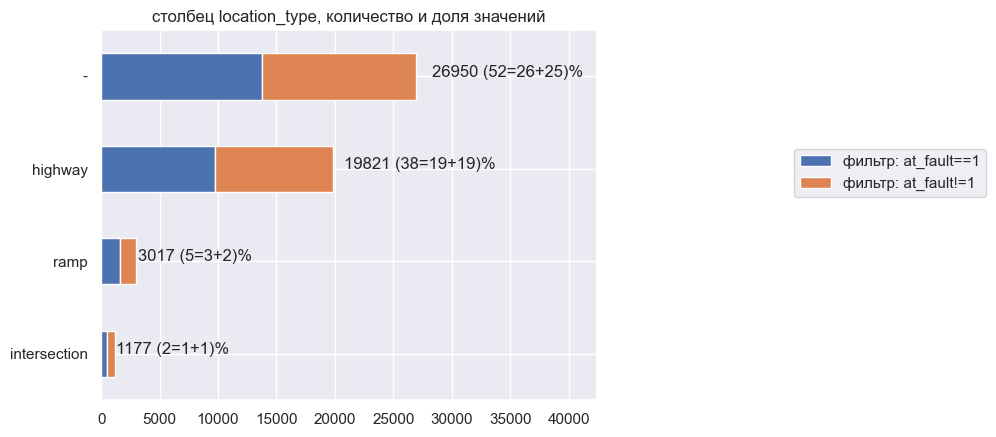

'⬇-------- столбец road_surface --------⬇'

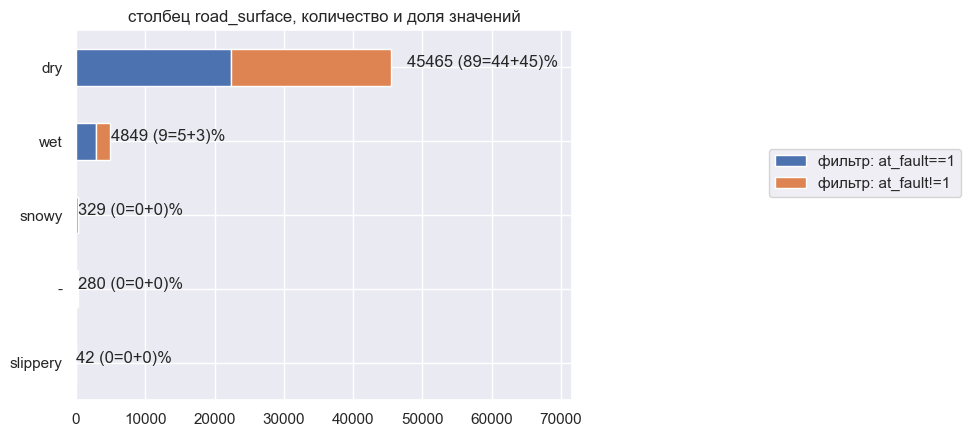

'⬇-------- столбец road_condition_1 --------⬇'

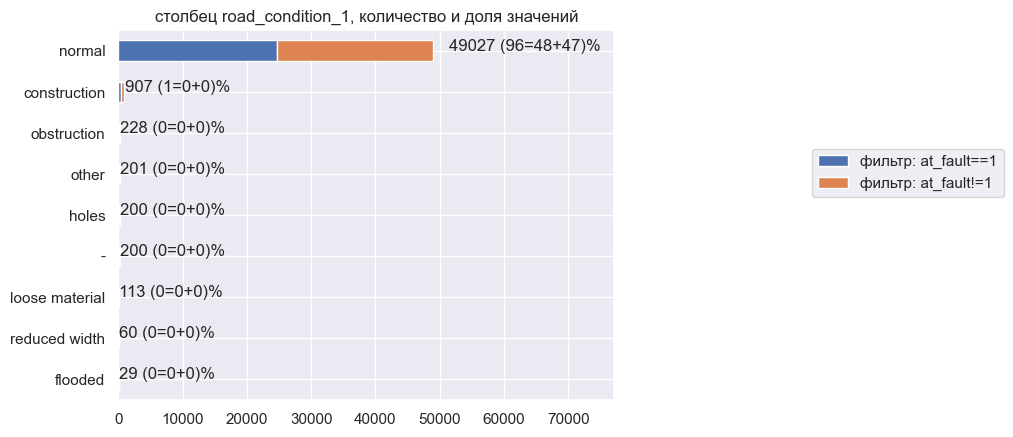

'⬇-------- столбец lighting --------⬇'

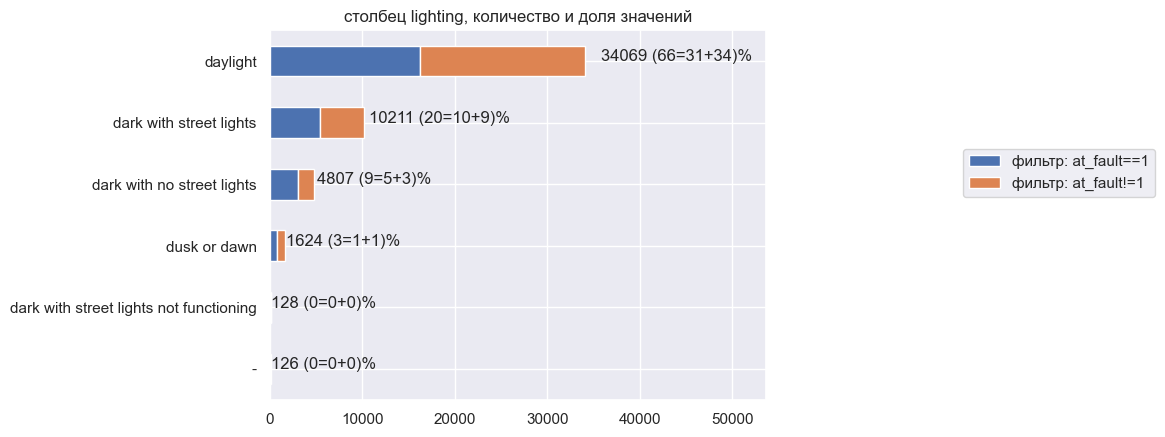

'⬇-------- столбец control_device --------⬇'

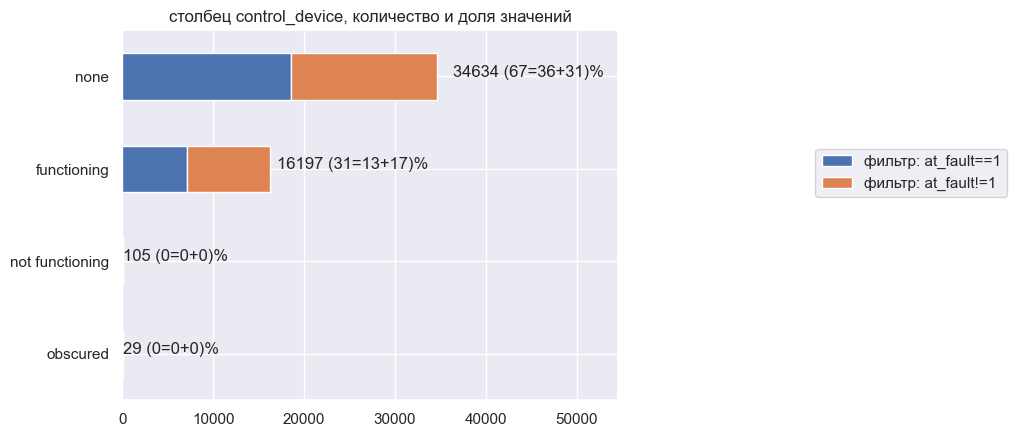

'⬇-------- столбец vehicle_type --------⬇'

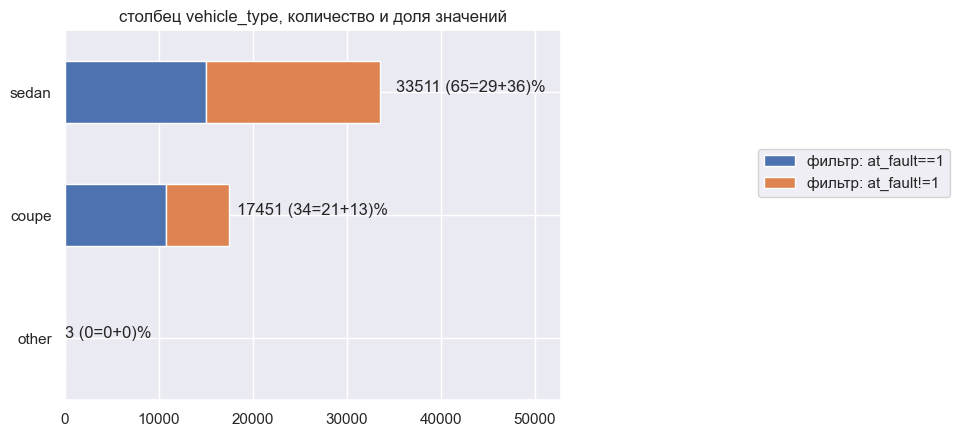

'⬇-------- столбец vehicle_transmission --------⬇'

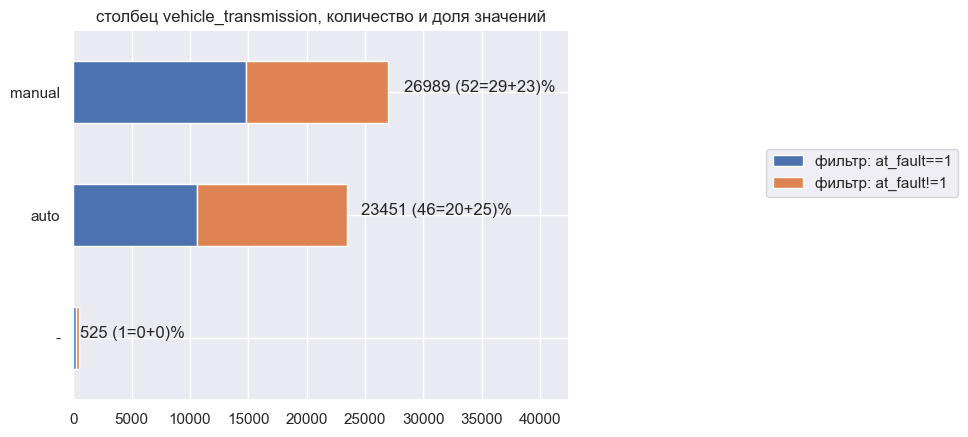

'⬇-------- Следующий признак: distance --------⬇'

'фильтр: at_fault==1'

count    2.570500e+04
mean     1.119445e+03
std      1.047137e+04
min      0.000000e+00
25%      2.000000e+01
50%      1.820000e+02
75%      7.500000e+02
max      1.584000e+06
Name: distance, dtype: float64

'фильтр: at_fault!=1'

count    25260.000000
mean       628.013677
std       1880.523134
min          0.000000
25%          0.000000
50%        100.000000
75%        528.000000
max      79200.000000
Name: distance, dtype: float64

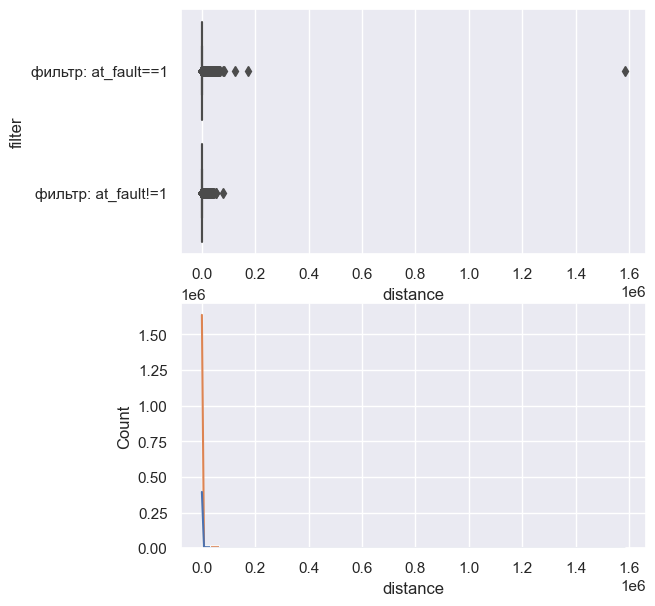

'⬇-------- Следующий признак: intersection --------⬇'

'фильтр: at_fault==1'

count    25705.000000
mean         0.185684
std          0.388859
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: intersection, dtype: float64

'фильтр: at_fault!=1'

count    25260.000000
mean         0.245249
std          0.430243
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: intersection, dtype: float64

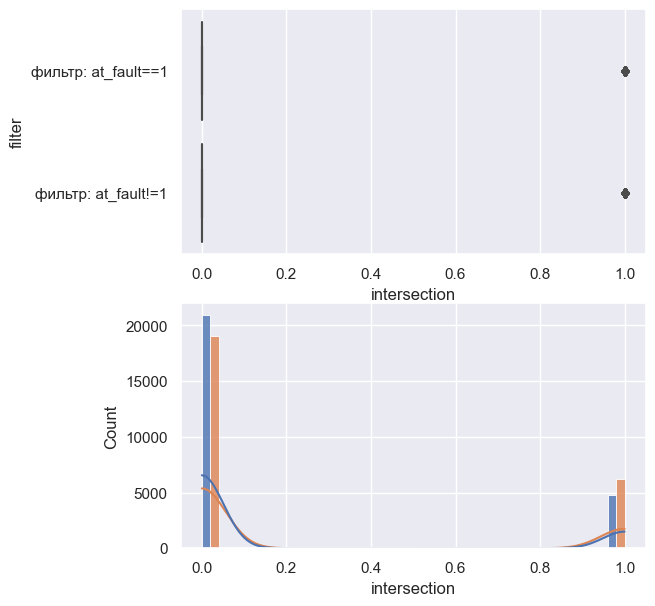

'⬇-------- Следующий признак: vehicle_age --------⬇'

'фильтр: at_fault==1'

count    25705.000000
mean         4.220152
std          2.472673
min          0.000000
25%          3.000000
50%          4.000000
75%          6.000000
max         10.000000
Name: vehicle_age, dtype: float64

'фильтр: at_fault!=1'

count    25260.000000
mean         4.617142
std          2.726587
min          0.000000
25%          3.000000
50%          4.000000
75%          7.000000
max         10.000000
Name: vehicle_age, dtype: float64

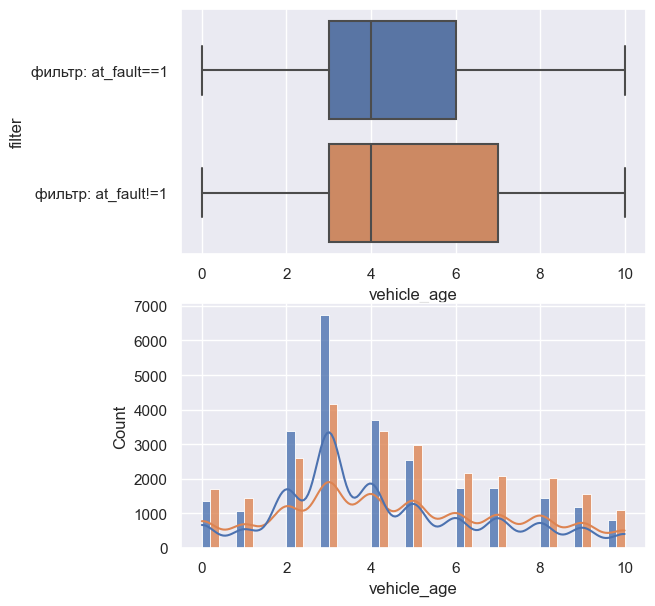

'⬇-------- Следующий признак: insurance_premium --------⬇'

'фильтр: at_fault==1'

count    25705.000000
mean        33.344719
std         14.119042
min          0.000000
25%         22.000000
50%         29.000000
75%         43.000000
max        102.000000
Name: insurance_premium, dtype: float64

'фильтр: at_fault!=1'

count    25260.000000
mean        38.049762
std         14.004872
min          0.000000
25%         26.000000
50%         36.000000
75%         48.000000
max        105.000000
Name: insurance_premium, dtype: float64

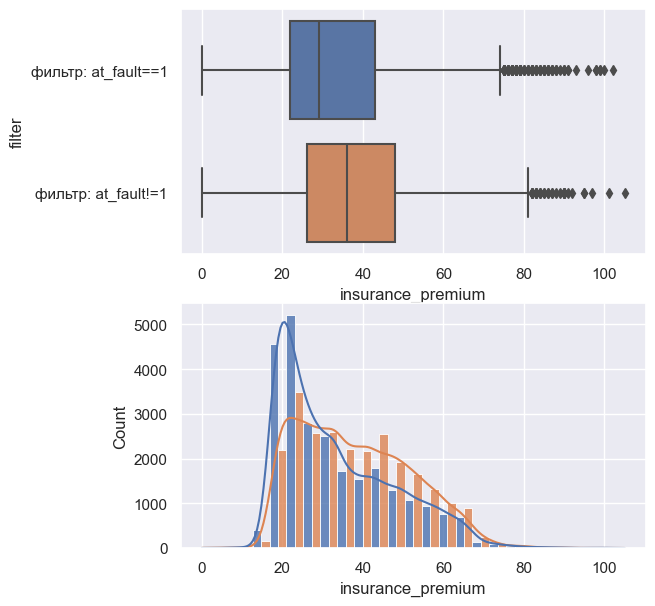

'⬇-------- Следующий признак: cellphone_in_use --------⬇'

'фильтр: at_fault==1'

count    25705.000000
mean         0.020696
std          0.142369
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: cellphone_in_use, dtype: float64

'фильтр: at_fault!=1'

count    25260.00000
mean         0.01730
std          0.13039
min          0.00000
25%          0.00000
50%          0.00000
75%          0.00000
max          1.00000
Name: cellphone_in_use, dtype: float64

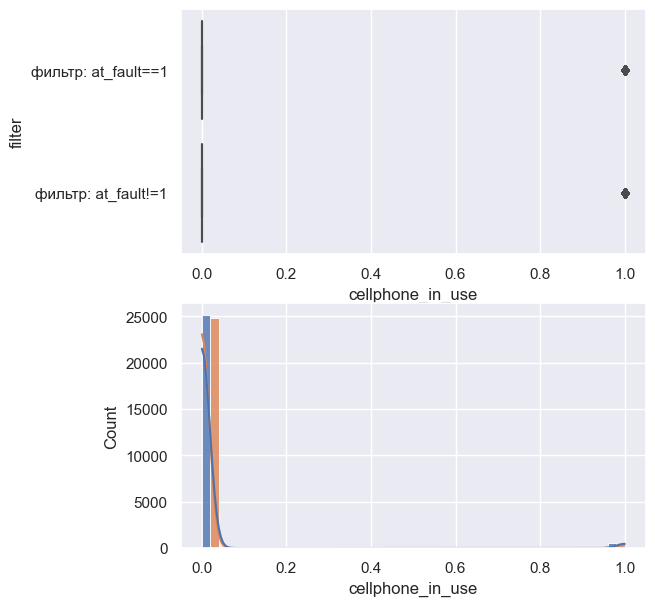

'⬇-------- Следующий признак: collision_date_year --------⬇'

'фильтр: at_fault==1'

count    25705.0
mean      2012.0
std          0.0
min       2012.0
25%       2012.0
50%       2012.0
75%       2012.0
max       2012.0
Name: collision_date_year, dtype: float64

'фильтр: at_fault!=1'

count    25260.0
mean      2012.0
std          0.0
min       2012.0
25%       2012.0
50%       2012.0
75%       2012.0
max       2012.0
Name: collision_date_year, dtype: float64

c:\Users\Papa\.conda\envs\practicum\lib\site-packages\seaborn\distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)
c:\Users\Papa\.conda\envs\practicum\lib\site-packages\seaborn\distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)


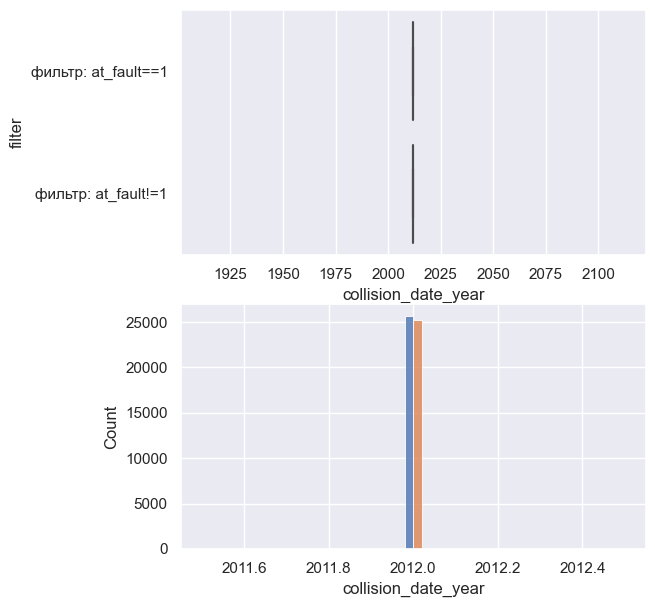

'⬇-------- Следующий признак: collision_date_month --------⬇'

'фильтр: at_fault==1'

count    25705.000000
mean         3.264190
std          1.835612
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         12.000000
Name: collision_date_month, dtype: float64

'фильтр: at_fault!=1'

count    25260.000000
mean         3.206215
std          1.759714
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         12.000000
Name: collision_date_month, dtype: float64

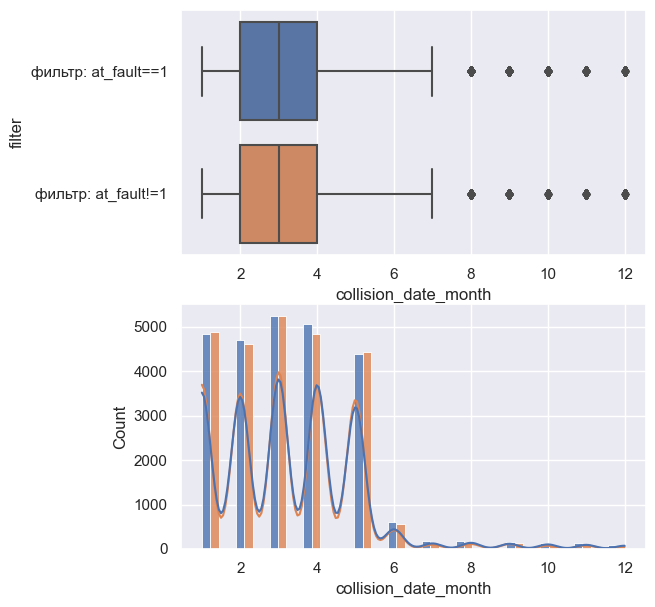

'⬇-------- Следующий признак: collision_date_day --------⬇'

'фильтр: at_fault==1'

count    25705.000000
mean        15.399066
std          8.707676
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         31.000000
Name: collision_date_day, dtype: float64

'фильтр: at_fault!=1'

count    25260.000000
mean        15.269279
std          8.719315
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         31.000000
Name: collision_date_day, dtype: float64

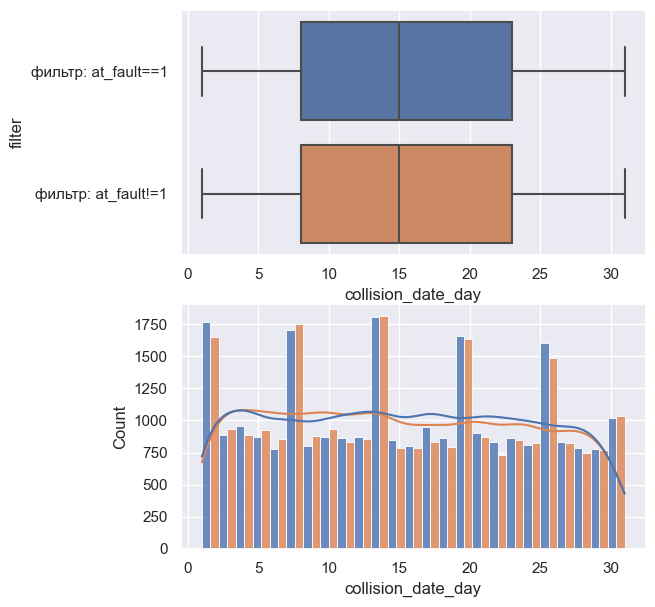

'⬇-------- Следующий признак: collision_date_weekday --------⬇'

'фильтр: at_fault==1'

count    25705.000000
mean         3.211671
std          1.985546
min          0.000000
25%          2.000000
50%          3.000000
75%          5.000000
max          6.000000
Name: collision_date_weekday, dtype: float64

'фильтр: at_fault!=1'

count    25260.000000
mean         3.138519
std          1.954573
min          0.000000
25%          1.000000
50%          3.000000
75%          5.000000
max          6.000000
Name: collision_date_weekday, dtype: float64

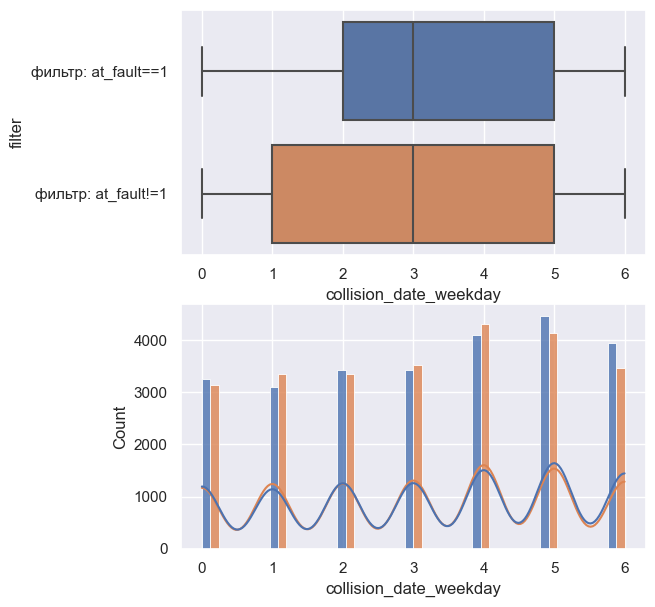

'⬇-------- Следующий признак: collision_time_hour --------⬇'

'фильтр: at_fault==1'

count    25705.000000
mean        12.838981
std          6.057165
min          0.000000
25%          8.000000
50%         14.000000
75%         17.000000
max         23.000000
Name: collision_time_hour, dtype: float64

'фильтр: at_fault!=1'

count    25260.000000
mean        13.776089
std          5.069889
min          0.000000
25%         11.000000
50%         14.000000
75%         17.000000
max         23.000000
Name: collision_time_hour, dtype: float64

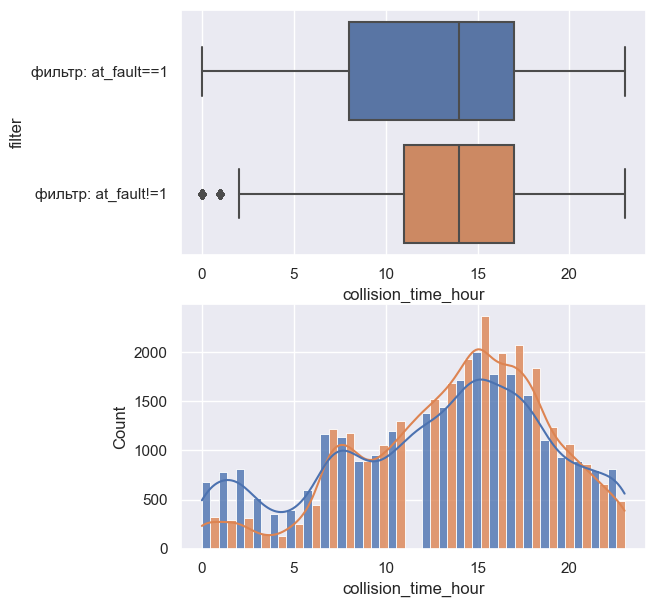

In [63]:
# отсортируем TOPы по самому критичному риску fatal:
do_eda(df, ignore_columns=['at_fault'],
       filters=['at_fault==1', 
                'at_fault!=1'],
        sort_filter_index=0)

#### выводы по повторному EDA
- Странно, конечно, что больше всего фатального ущерба - днём в ясную погоду и на сухой дороге. Возможно дело в том, что разгоняются сильнее всего именно в такую погоду (судя по pcf_violation_category из первого EDA)
- У виновных машины новее.
- У виновных средняя страховка меньше (30 против 38). 
- Почему-то для выборки, построенной для тренировки модели - ДТП в первом полугодии, а во втором их почти нет Это странно...
- Больше всего аварий автомобилей по Пт и Сб.

### Проверим мультиколлинеарность

In [64]:
df.head()

,at_fault,county_city_location,county_location,distance,direction,intersection,weather_1,location_type,road_surface,road_condition_1,...,vehicle_type,vehicle_transmission,vehicle_age,insurance_premium,cellphone_in_use,collision_date_year,collision_date_month,collision_date_day,collision_date_weekday,collision_time_hour
0,1,3711,san diego,1500.0,south,0.0,clear,highway,dry,normal,...,sedan,manual,3,33.0,0.0,2012,1,20,4,1
1,0,1101,glenn,55.0,north,0.0,cloudy,-,wet,normal,...,sedan,auto,3,20.0,0.0,2012,4,11,2,14
2,1,3010,orange,0.0,east,0.0,clear,-,dry,normal,...,sedan,auto,3,21.0,0.0,2012,4,17,1,17
3,0,3604,san bernardino,1584.0,south,0.0,cloudy,ramp,dry,normal,...,sedan,auto,5,33.0,0.0,2012,4,25,2,19
4,1,4000,san luis obispo,50.0,north,0.0,clear,-,dry,normal,...,sedan,auto,3,23.0,0.0,2012,4,28,5,8


c:\Users\Papa\.conda\envs\practicum\lib\site-packages\phik\data_quality.py:82: UserWarning: Not enough unique value for variable collision_date_year for analysis 1. Dropping this column
  warnings.warn(


'Мультиколлинеарные фичи для удаления:'

[]

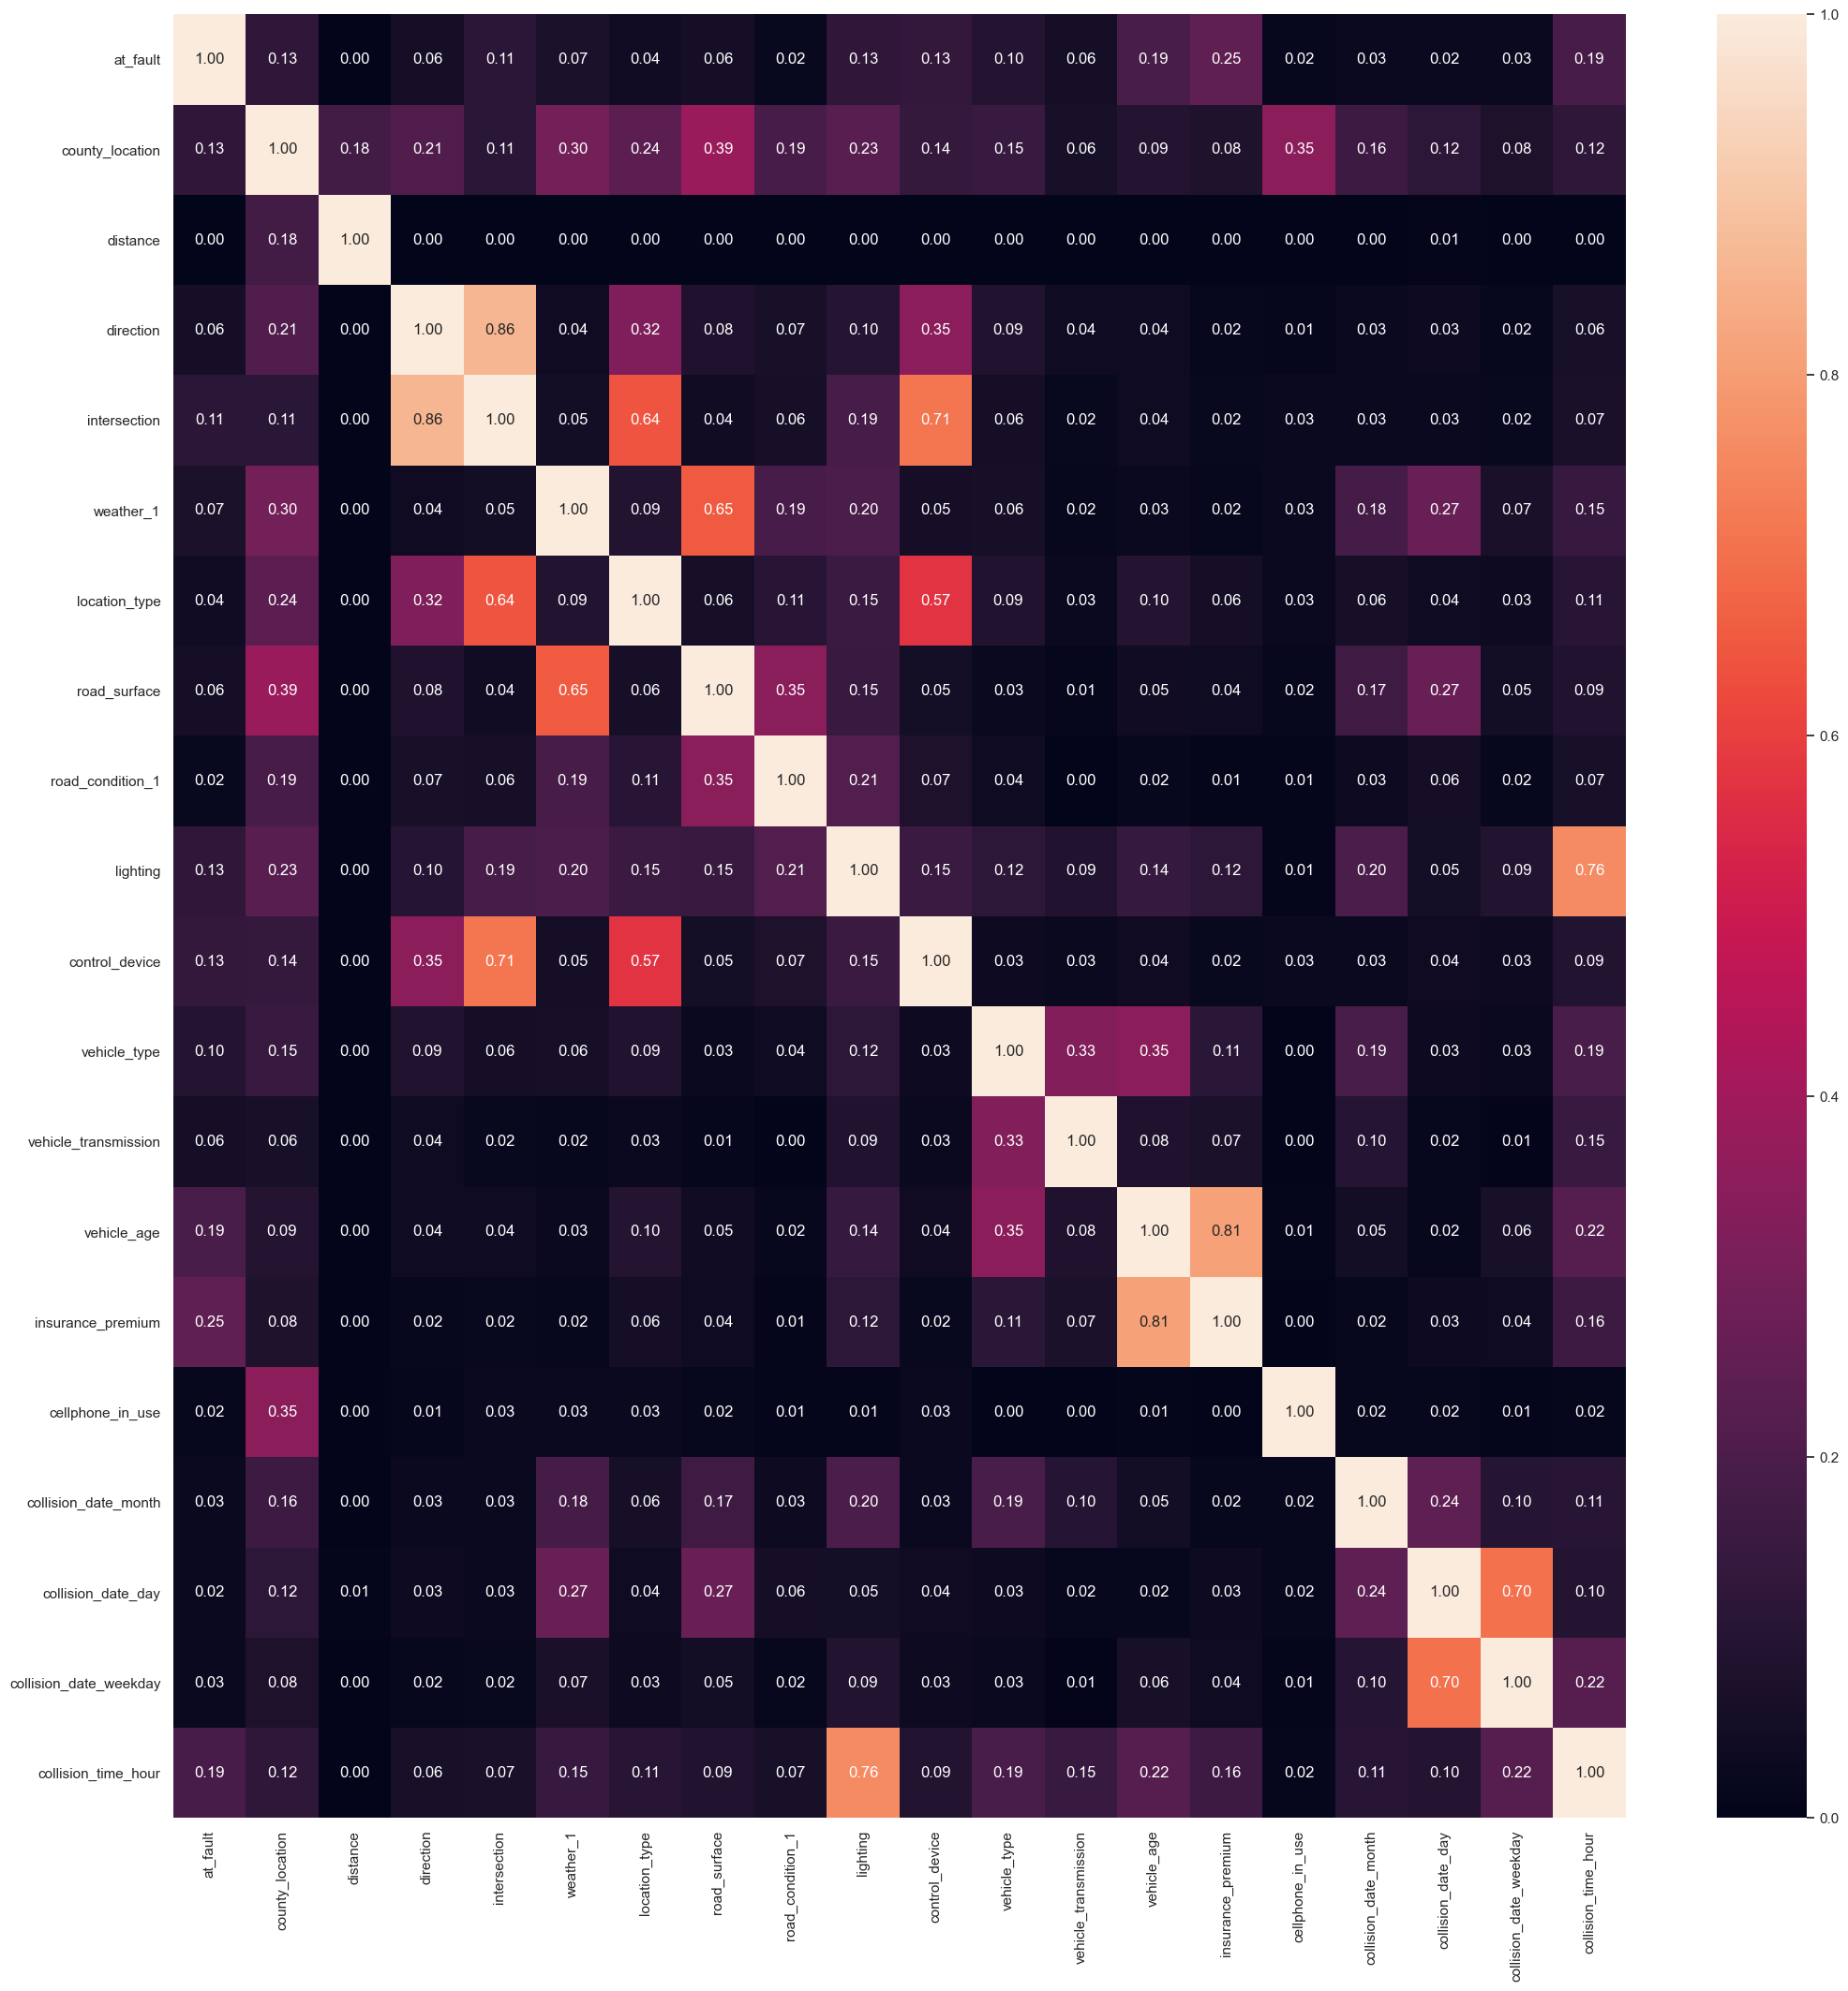

In [65]:
interval_cols=['distance', 'county_city_location', 'vehicle_age', 'insurance_premium']
   
bins = {}
for c in interval_cols:
    bins[c] = 10;

_, ax = plt.subplots(figsize=(25,25))
ph_mx = df.drop('county_city_location', axis=1).phik_matrix(interval_cols=interval_cols, bins=bins)
sns.heatmap(ph_mx, annot=True, fmt='.2f', ax=ax);

columns_to_delete, ph_mx_no_mc = get_multicollinear_features (ph_mx)
display ("Мультиколлинеарные фичи для удаления:")
display (columns_to_delete)

*Как правило, о мультиколлинеарности говорят при значении коэффициента корреляции от 0.9 до 0.95 по модулю. В такой ситуации лишние коррелирующие признаки нужно удалять из обучающей выборки.*

Поменяем тип полей object на category для catboost.

In [67]:
df = df.drop('collision_date_year', axis=1)

In [68]:
cat_features = df.select_dtypes(include=["object"]).columns.tolist()
cat_features += ['cellphone_in_use', 'collision_date_month', 
                 'collision_date_day', 'collision_time_hour']

In [69]:
df[cat_features] = df[cat_features].select_dtypes(include=['object', 'number']).astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 50965 entries, 0 to 54551
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   at_fault                50965 non-null  int64   
 1   county_city_location    50965 non-null  category
 2   county_location         50965 non-null  category
 3   distance                50965 non-null  float64 
 4   direction               50965 non-null  category
 5   intersection            50965 non-null  float64 
 6   weather_1               50965 non-null  category
 7   location_type           50965 non-null  category
 8   road_surface            50965 non-null  category
 9   road_condition_1        50965 non-null  category
 10  lighting                50965 non-null  category
 11  control_device          50965 non-null  category
 12  vehicle_type            50965 non-null  category
 13  vehicle_transmission    50965 non-null  category
 14  vehicle_age           

### Проверим сбалансированность выборки

In [70]:
df['at_fault'].value_counts()

1    25705
0    25260
Name: at_fault, dtype: int64

Классы сбалансированы.

In [71]:
X = df.drop('at_fault', axis=1)
y = df['at_fault']

### Пайплйн с обучением моделей

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
cat_columns = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_columns = X_train.select_dtypes(include=["number"]).columns.tolist()

In [74]:
df['weather_1'].unique()

['clear', 'cloudy', 'raining', 'fog', '-', 'snowing', 'other', 'wind']
Categories (8, object): ['clear', 'cloudy', 'raining', 'fog', '-', 'snowing', 'other', 'wind']

In [75]:
df['road_surface'].unique()

['dry', 'wet', 'snowy', '-', 'slippery']
Categories (5, object): ['dry', 'wet', 'snowy', '-', 'slippery']

In [76]:
df['road_condition_1'].unique()

['normal', '-', 'obstruction', 'construction', 'reduced width', 'holes', 'other', 'loose material', 'flooded']
Categories (9, object): ['normal', '-', 'obstruction', 'construction', ..., 'holes', 'other', 'loose material', 'flooded']

In [77]:
df['lighting'].unique()

['dark with street lights', 'daylight', 'dark with no street lights', 'dusk or dawn', '-', 'dark with street lights not functioning']
Categories (6, object): ['dark with street lights', 'daylight', 'dark with no street lights', 'dusk or dawn', '-', 'dark with street lights not functioning']

In [78]:
df['control_device'].unique()

['none', 'functioning', 'obscured', 'not functioning']
Categories (4, object): ['none', 'functioning', 'obscured', 'not functioning']

In [ ]:
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'))
    ])

ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))]
)

data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, cat_columns),
##v2        ('ord', ord_pipe, ord_columns),
        ('num', StandardScaler(), num_columns),
    ], 
    remainder='passthrough'
) 


В качестве метрики выберем recall_macro, т. к. выявить риск важнее, чем перестраховаться.

In [80]:
%%time

pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', RandomForestClassifier())
])

param_grid = [
#    {
#        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced')],
#        'models__max_depth': [4,7],
#        'models__max_features': [10, 50],
#        'preprocessor__num': [StandardScaler(), MinMaxScaler()]   
#    }
#    ,
    {
        'models': [RandomForestClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': [10, 20],
        'models__min_samples_split': [5, 10],
        'models__min_samples_leaf': [2, 4],
        'models__bootstrap': [True, False],
        'preprocessor__num': [MinMaxScaler()]   
    }
    ,
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1',
            class_weight='balanced'
        )],
        'models__C': range(1, 3),
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]   
    },
    {
        'models': [CatBoostClassifier(verbose=0, random_seed=RANDOM_STATE)],
        "models__learning_rate": [0.03, 0.1, 1],
        "models__iterations": [100, 300],
        "models__max_depth": [2, 10],
        "models__colsample_bylevel": [0.1, 0.3, 0.8],
        "models__l2_leaf_reg": [0,10],
        "models__bagging_temperature": [0,10]

    }    
#    ,
#    {
#        'models': [SVC(
#            random_state=RANDOM_STATE, 
#            kernel='linear', probability=True, class_weight='balanced'
#        )],
#        'models__kernel': ['poly', 'rbf'],
#        'models__degree': [2, 5, 10],
#        'models__C': range(2, 3),
#    }
]

search = RandomizedSearchCV(
    pipe_final, 
    param_grid,
    cv=3,
    scoring='f1',
    n_iter=30,
    verbose = 10,
    n_jobs=-1
)

search.fit(X_train, y_train)

search.best_params_

best_model = search.best_estimator_

Fitting 3 folds for each of 30 candidates, totalling 90 fits
CPU times: total: 27.6 s
Wall time: 4min 12s


In [81]:
search.best_params_

{'models__max_depth': 2,
 'models__learning_rate': 0.1,
 'models__l2_leaf_reg': 10,
 'models__iterations': 300,
 'models__colsample_bylevel': 0.8,
 'models__bagging_temperature': 10,
 'models': <catboost.core.CatBoostClassifier at 0x17e8c880a30>}

In [82]:
best_model = search.best_estimator_

## Метрики качества на валидационной выборке

In [83]:
display ('Метрика качества лучшей модели на кроссвалидации: ', search.best_score_)

'Метрика качества лучшей модели на кроссвалидации: '

0.6307452194185745

## Метрики качества на тестовой выборке

In [84]:
# оценка классификации

y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.62      0.66      0.64      5052
           1       0.65      0.60      0.62      5141

    accuracy                           0.63     10193
   macro avg       0.63      0.63      0.63     10193
weighted avg       0.63      0.63      0.63     10193



c:\Users\Papa\.conda\envs\practicum\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


c:\Users\Papa\.conda\envs\practicum\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


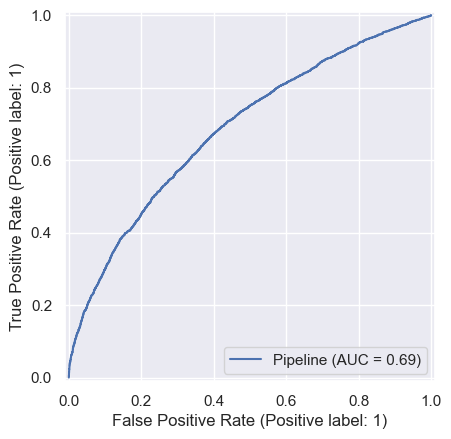

In [85]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test);

c:\Users\Papa\.conda\envs\practicum\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


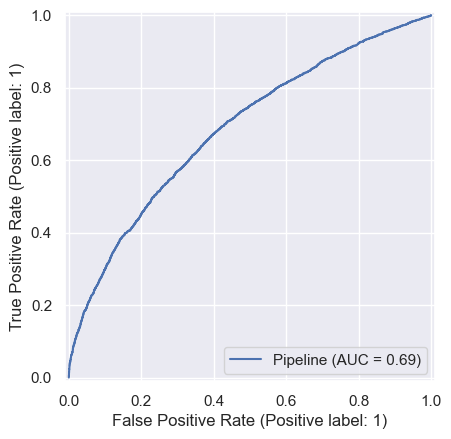

In [86]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test);

## Найдите лучшую модель

In [87]:
display(search.best_params_)

{'models__max_depth': 2,
 'models__learning_rate': 0.1,
 'models__l2_leaf_reg': 10,
 'models__iterations': 300,
 'models__colsample_bylevel': 0.8,
 'models__bagging_temperature': 10,
 'models': <catboost.core.CatBoostClassifier at 0x17e8c880a30>}

## Проверьте лучшую модель в работе

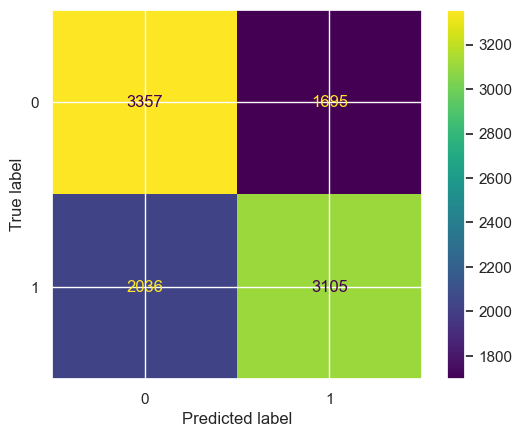

In [88]:
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=best_model.classes_)
disp.plot();

## Проведите анализ важности факторов ДТП

c:\Users\Papa\.conda\envs\practicum\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


  0%|          | 0/20 [00:00<?, ?it/s]

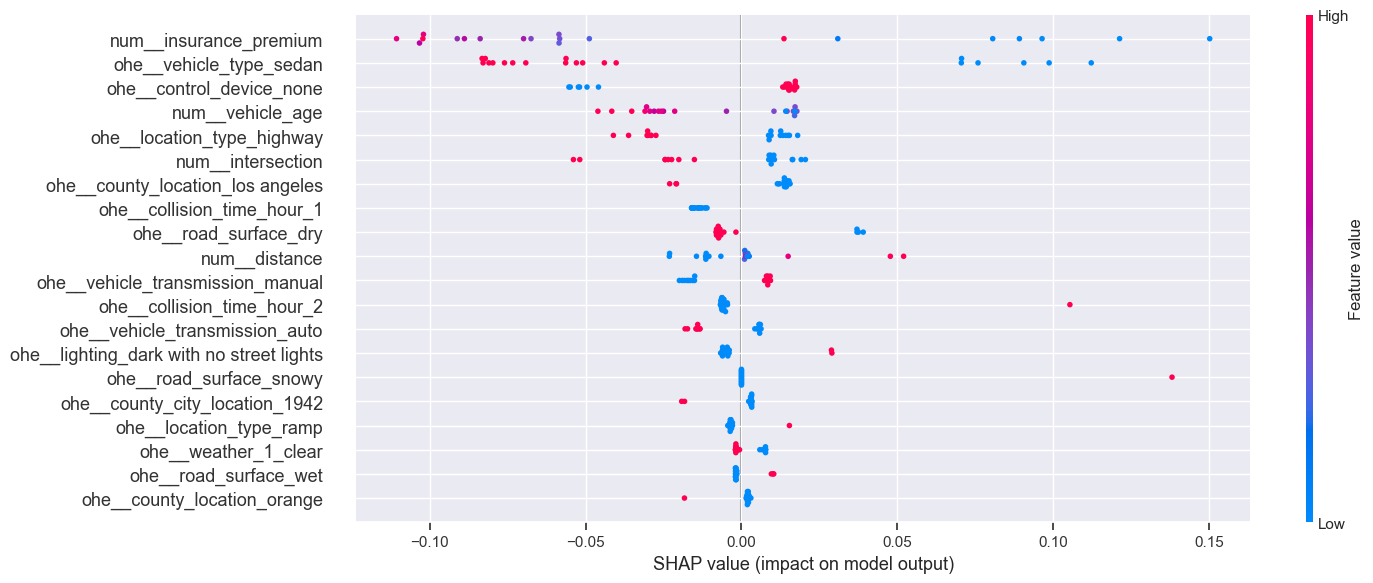

In [89]:
samples = 20
 
# Извлечение лучшей модели из результатов RandomizedSearchCV
best_model = search.best_estimator_.named_steps['models']

# Предобработка данных через пайплайн без конечной модели
preprocessor = search.best_estimator_.named_steps['preprocessor']
X_train_preprocessed = preprocessor.transform(X_train)
X_train_dense = X_train_preprocessed.toarray()
X_test_preprocessed = preprocessor.transform(X_test)
X_test_dense = X_test_preprocessed.toarray()

all_feature_names = preprocessor.get_feature_names_out()

# Создаем DataFrame с соответствующими именами колонок
X_train_preprocessed_df = pd.DataFrame(X_train_dense, 
                                       columns=all_feature_names)
X_test_preprocessed_df = pd.DataFrame(X_test_dense, 
                                      columns=all_feature_names)

# Семпл данных для KernelExplainer
X_train_preprocessed_smpl = shap.sample(X_train_preprocessed_df, 
                                        samples, random_state=RANDOM_STATE)
X_test_preprocessed_smpl = shap.sample(X_test_preprocessed_df, 
                                       samples, random_state=RANDOM_STATE)

# Теперь, когда у нас есть DataFrame с именами признаков, мы можем использовать KernelExplainer
###explainer = shap.KernelExplainer(best_model.predict_proba, X_train_preprocessed_smpl)
explainer = shap.KernelExplainer(best_model.predict_proba, X_train_preprocessed_smpl)
shap_values = explainer.shap_values(X_test_preprocessed_smpl)

# Создаем объект Explanation для первого КЛАССА.
shap_values_explanation = shap.Explanation(
    values=shap_values[:,:,1], 
    base_values=explainer.expected_value,
    data=X_test_preprocessed_smpl,
    feature_names=all_feature_names
)

shap.summary_plot(shap_values_explanation, plot_size=[15,6])
plt.show()


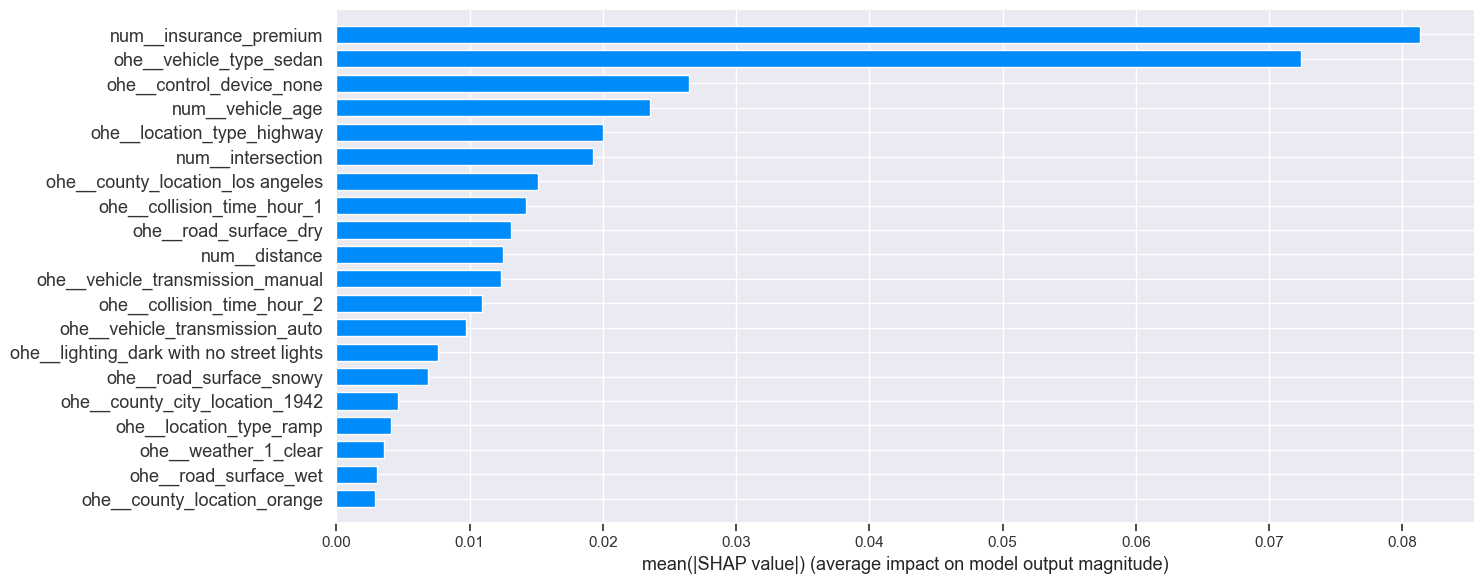

In [90]:
shap.summary_plot(shap_values_explanation, plot_size=[15,6], plot_type='bar')
plt.show()

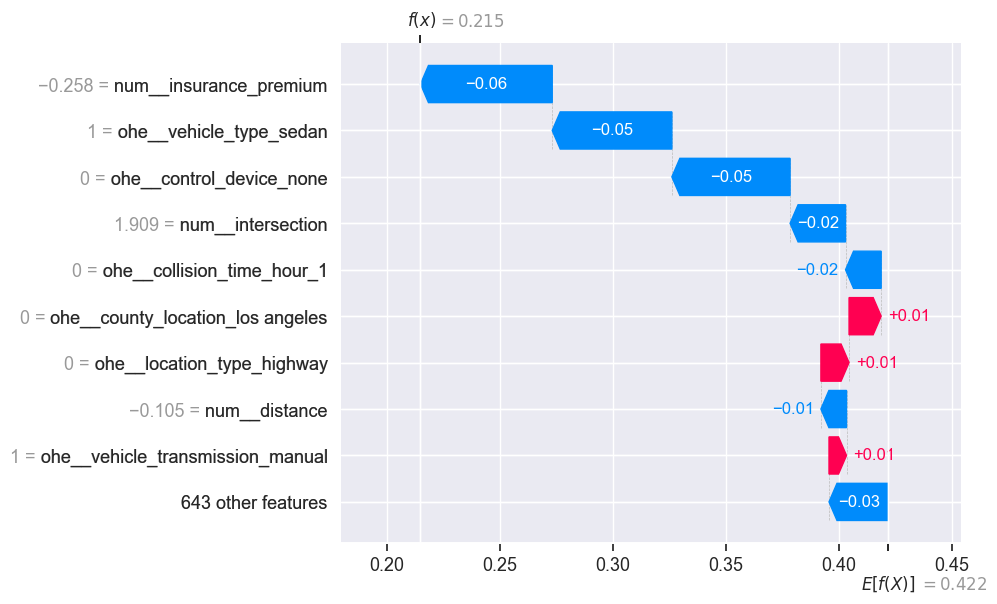

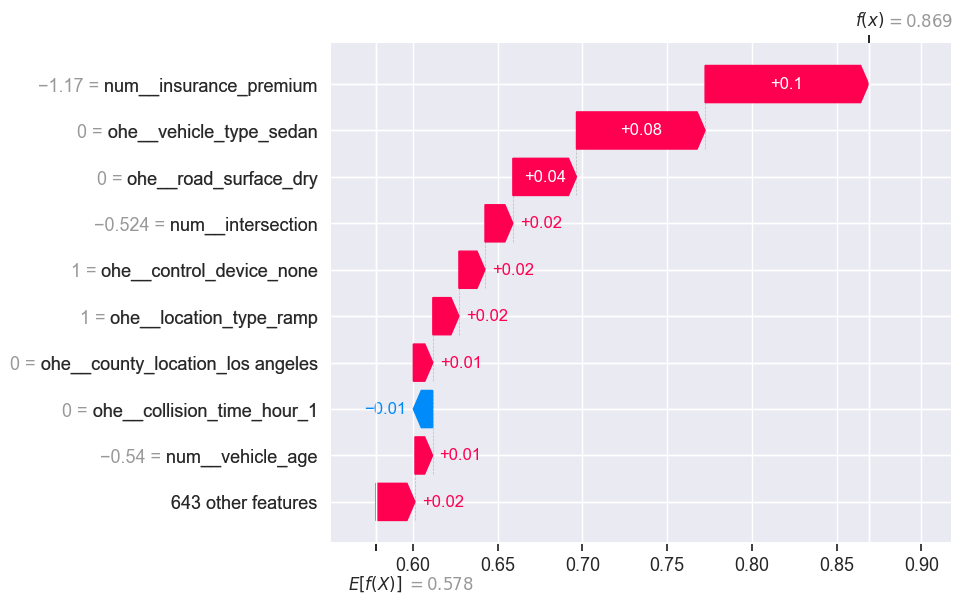

In [91]:
shap.plots.waterfall(shap_values_explanation[0]);
shap.plots.waterfall(shap_values_explanation[1]);
plt.show()

Наиболее важные с т. з. модели признаки:
1. vehicle_type (sedan)
1. insurance_premium

Оценим график зависимости фактора и целевой переменной:

'⬇-------- столбец vehicle_type --------⬇'

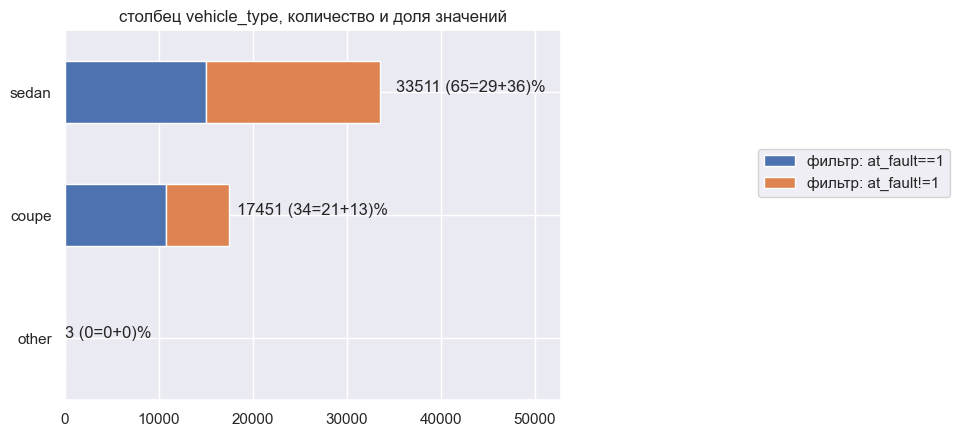

'⬇-------- Следующий признак: insurance_premium --------⬇'

'фильтр: at_fault==1'

count    25705.000000
mean        33.344719
std         14.119042
min          0.000000
25%         22.000000
50%         29.000000
75%         43.000000
max        102.000000
Name: insurance_premium, dtype: float64

'фильтр: at_fault!=1'

count    25260.000000
mean        38.049762
std         14.004872
min          0.000000
25%         26.000000
50%         36.000000
75%         48.000000
max        105.000000
Name: insurance_premium, dtype: float64

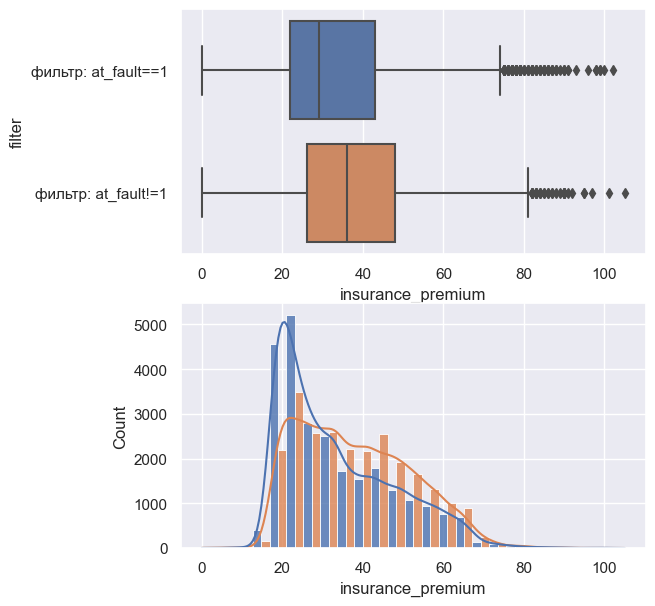

In [92]:
do_eda(df, columns=['vehicle_type', 'insurance_premium'], filters=["at_fault==1", "at_fault!=1"])

График не отражает значительных отличий в поседении виновников и невиновных в зависимости от этих двух признаков.

## Выводы

- В соответствии с поставленной задачей(см. первый раздел)
    - была проведена подготовка данных и их разведочный анализ, в результате которых:
        - были исправлены типы данных, удалены малополезные признаки (в т. ч. с учётом мультиколлинеарности), обработаны пропуски
    - была натренирована модель, предсказывающая ...
        - выбрана наиболее оптимальная модель - **CatBoostClassifier**, показавшая наилучшие результаты на тестовой выборке:
            - качество предсказания: **precision = 0.65, recall  = 0.60**
                - надеюсь, ревьюер подскажет, как улучшить метрики, спасибо
            - это не удовлетворяет заданному самостоятельно критерию качества: Precision >= 70\%, Recall >= 95%
- выводы по итогам разведочного анализа:
    - наиболее массовый случай - это нарушение ПДД на скоростных дорогах между двумя участниками с малозначительными повреждениями (подробнее см. раздел "Выводы и задачи по итогам EDA")
    - наиболее рискованно ездить - на более старых машинах, не оборудованных control_device, чрезмерно надеясь на страховку (подробнее см. раздел "выводы по повторному EDA").
- попутные наблюдения
    - в документации пропущено описание признака control_device

Исходя из выводов выше отвечая на вопрос исследования:
- **RQ1**: Возможно ли создать адекватную системы оценки водительского риска при выдаче авто?
    - да, можно построить модель для оценки уровня риска выбранного маршрута в выбранное время на выбранном авто (и водителе)
- **RQ2**: Какие ещё факторы нужно учесть?
    - Больше  ДТП у машин, у которых нет control_device (видимо, датчик контроля полосы итд). Это - хороший аргумент в пользу установки такого оборудования на арендуемых машины.
    - Может помочь "портрет" водителя и история его поездок. Но таких данных в базе сейчас нет - их стоит добавить в базу и модель.
- **RQ3**: Нужно ли оборудовать автомобиль какими-либо датчиками или камерой?
    - стоит оборудовать автомобили control_device
    - не стоит допускать старые автомобили в парк автомобилей